<div style='background: linear-gradient(135deg, #667eea 0%, #b1d54e 100%); padding: 40px; border-radius: 15px; box-shadow: 0 10px 30px rgba(0,0,0,0.3);'>
    <h1 style='color: white; text-align: center; font-size: 48px; margin: 0; font-weight: 800; text-shadow: 2px 2px 4px rgba(0,0,0,0.3);'>HELP ONG x VisionDataLab</h1>
    <h2 style='color: #e0e7ff; text-align: center; font-size: 28px; margin-top: 15px; font-weight: 300;'>Modelisation</h2>
    <p style='color: white; text-align: center; font-size: 16px; margin-top: 20px; opacity: 0.9;'>TP ML 2</p>
</div>

# Imports and config

In [44]:
import sys
from pathlib import Path

root = Path.cwd().parent
if str(root) not in sys.path:
    sys.path.append(str(root))

from src.config import paths
from src.utils.country import apply_ne_mapping

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from time import time

from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                              calinski_harabasz_score, adjusted_rand_score,
                              confusion_matrix)
import geopandas as gpd
import matplotlib.patches as mpatches
import joblib

SEED    = 42
K_RANGE = range(2, 9)
PALETTE = ['#2E86AB', '#E84855', '#3BB273', '#F18F01', '#C490D1', '#A23B72', '#F5E6CA']
N_RUNS  = 100

np.random.seed(SEED)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

# Chargement des données

In [45]:
df_raw    = pd.read_csv(paths.DATA_DIR / 'final' / 'final_main_data.csv')
df_enrich = pd.read_csv(paths.DATA_DIR / 'final' / 'final_enriched_data.csv')

id_col_r   = 'country'
num_cols_r = df_raw.select_dtypes(include=np.number).columns.tolist()

id_cols_e  = ['country', 'iso_code']
num_cols_e = [c for c in df_enrich.columns if c not in id_cols_e]

print('Dataset classique  :', df_raw.shape)
print('Variables          :', num_cols_r)
print()
print('Dataset enrichi    :', df_enrich.shape)
print('Variables          :', num_cols_e)

Dataset classique  : (167, 9)
Variables          : ['life_expec', 'child_mort_log', 'total_fer', 'gdpp_log', 'health', 'inflation_log', 'exports_log', 'imports_log']

Dataset enrichi    : (167, 16)
Variables          : ['physicians_per_1000', 'hiv_prevalence_log', 'life_expec', 'child_mort_log', 'vaccination_dpt_log', 'gdpp_log', 'inflation_log', 'social_undernourishment_log', 'social_poverty_2_15_log', 'social_schooling_log', 'security_apparatus', 'group_grievance', 'refugees_idps', 'external_intervention']


### Chargement du fond de carte Natural Earth

In [46]:
_ne_cache = paths.ROOT_DIR / 'scratch' / '_ne_world.gpkg'
_ne_url   = 'https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip'
if not _ne_cache.exists():
    world = gpd.read_file(_ne_url)
    _ne_cache.parent.mkdir(parents=True, exist_ok=True)
    world.to_file(str(_ne_cache), driver='GPKG')
    print('Fond de carte téléchargé et mis en cache.')
else:
    world = gpd.read_file(str(_ne_cache))
    print('Fond de carte chargé depuis le cache.')



Fond de carte chargé depuis le cache.


> Noter que les petits pays environ 10 seront afiché comme non couvert sur les cartes car non inclu dans ,'https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip'

---
# Partie I : Dataset classique

## Mise à l'échelle

La normalisation est nécessaire car les 8 variables ont des unités et des dynamiques très différentes . Sans normalisation, les variables à grande amplitude écraseront les distances euclidiennes.

Le choix du `RobustScaler` (centrage sur la médiane, réduction par l'écart interquartile) plutôt que le `StandardScaler` (centrage sur la moyenne) est motivé par les outliers légitimes documentés en P1 : des pays comme le Luxembourg (exports_log extrême) ou le Niger (total_fer extrême) ne doivent pas distordre l'échelle. Le RobustScaler les préserve sans les amplifier.

In [47]:
scaler_r = RobustScaler()
X_raw    = scaler_r.fit_transform(df_raw[num_cols_r])
print(f'Matrice : {X_raw.shape[0]} pays × {X_raw.shape[1]} variables')

Matrice : 167 pays × 8 variables


In [48]:
X_raw

array([[-1.46956522,  0.78218678,  1.63549161, ...,  0.3431287 ,
        -1.5869512 ,  0.05460474],
       [ 0.27826087, -0.07430293, -0.36450839, ..., -0.10610696,
        -0.28941352,  0.17391757],
       [ 0.29565217,  0.17296896,  0.23021583, ...,  0.68802128,
         0.12079498, -0.48144263],
       ...,
       [ 0.        ,  0.09363511, -0.2206235 , ...,  0.50177094,
         0.94623624,  0.93253302],
       [-0.48695652,  0.54022963,  1.08393285, ...,  0.94221215,
        -0.20014746, -0.3451581 ],
       [-1.83478261,  0.73999196,  1.43405276, ...,  0.59643722,
         0.0723687 , -0.50537795]], shape=(167, 8))

## Analyse en Composantes Principales

L'ACP est utilisée ici dans un rôle de diagnostic et de visualisation, non comme étape de réduction dimensionnelle préalable au clustering. Le clustering sera réalisé dans l'espace normalisé (8 variables pour le classique, 14 pour l'enrichi). réduire la dimension avant de clustériser ferait perdre une partie du signal que les composantes tardives peuvent contenir, notamment pour discriminer des sous-groupes subtils.

L'ACP sert deux objectifs ici. Le premier est de vérifier que les variables ne sont pas toutes indépendantes : si la première composante concentre déjà 40-50 % de la variance, cela confirme qu'il existe une structure latente exploitable par le clustering. Le second objectif est de permettre une visualisation 2D des partitions obtenues, même si cette projection ne restitue qu'une fraction de l'information totale.

Le cercle de corrélation complète cette analyse en montrant, pour chaque variable, sa corrélation avec les deux premières composantes. Il permet d'identifier les variables redondantes , les variables orthogonales (flèches perpendiculaires), et les variables mal représentées sur le plan principal (flèches courtes). Ces informations valident rétrospectivement les choix de sélection de variables effectués en P1.

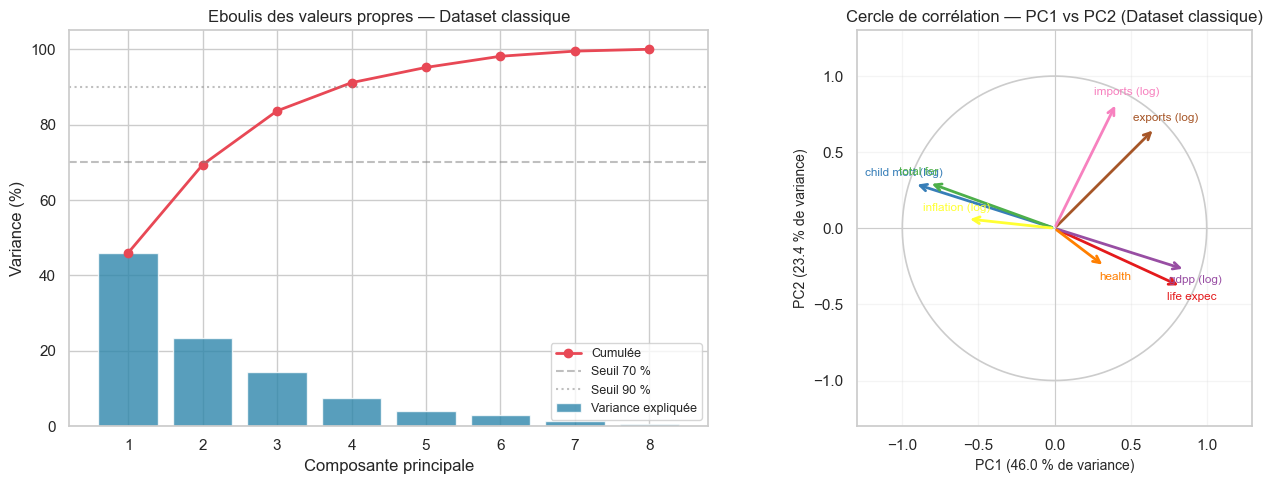

PC1 : 46.0%  |  PC2 : 23.4%  |  PC1+PC2 : 69.4%
PC1+PC2+PC3 : 83.6%
90 % de variance atteint à PC4


In [49]:
pca_r = PCA(random_state=SEED)
pca_r.fit(X_raw)

var_exp = pca_r.explained_variance_ratio_
cum_var = np.cumsum(var_exp)

# Coordonnées du cercle de corrélation : corrélation entre chaque variable et chaque PC
X_pca_full_r = pca_r.transform(X_raw)
n_feat_r     = len(num_cols_r)
corr_mat_r   = np.corrcoef(X_raw.T, X_pca_full_r.T)
coords_cc_r  = corr_mat_r[:n_feat_r, n_feat_r:n_feat_r + 2]   # (n_feat, 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].bar(range(1, len(var_exp)+1), var_exp * 100, color='#2E86AB', alpha=0.8,
            label='Variance expliquée')
axes[0].plot(range(1, len(cum_var)+1), cum_var * 100, 'o-', color='#E84855',
             linewidth=2, label='Cumulée')
axes[0].axhline(70, color='gray', linestyle='--', alpha=0.5, label='Seuil 70 %')
axes[0].axhline(90, color='gray', linestyle=':', alpha=0.5, label='Seuil 90 %')
axes[0].set_xlabel('Composante principale')
axes[0].set_ylabel('Variance (%)')
axes[0].set_title('Eboulis des valeurs propres — Dataset classique')
axes[0].legend(fontsize=9)

#  Cercle de corrélation 
theta = np.linspace(0, 2 * np.pi, 300)
axes[1].plot(np.cos(theta), np.sin(theta), color='#CCCCCC', linewidth=1.2, zorder=1)
axes[1].axhline(0, color='#CCCCCC', linewidth=0.8, zorder=1)
axes[1].axvline(0, color='#CCCCCC', linewidth=0.8, zorder=1)

colors_cc = plt.cm.Set1(np.linspace(0, 0.8, n_feat_r))
for j, var in enumerate(num_cols_r):
    xc, yc = coords_cc_r[j, 0], coords_cc_r[j, 1]
    axes[1].annotate('', xy=(xc, yc), xytext=(0, 0),
                     arrowprops=dict(arrowstyle='->', color=colors_cc[j], lw=2.0),
                     zorder=3)
    offset_x = 0.07 if xc >= 0 else -0.07
    offset_y = 0.07 if yc >= 0 else -0.07
    label = var.replace('_log', ' (log)').replace('_', ' ')
    axes[1].text(xc + offset_x, yc + offset_y, label,
                 fontsize=8.5, color=colors_cc[j], ha='center', va='center', zorder=4)

axes[1].set_xlim(-1.3, 1.3)
axes[1].set_ylim(-1.3, 1.3)
axes[1].set_aspect('equal')
axes[1].set_xlabel(f'PC1 ({var_exp[0]*100:.1f} % de variance)', fontsize=10)
axes[1].set_ylabel(f'PC2 ({var_exp[1]*100:.1f} % de variance)', fontsize=10)
axes[1].set_title('Cercle de corrélation — PC1 vs PC2 (Dataset classique)')
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print(f'PC1 : {var_exp[0]*100:.1f}%  |  PC2 : {var_exp[1]*100:.1f}%  |  PC1+PC2 : {cum_var[1]*100:.1f}%')
print(f'PC1+PC2+PC3 : {cum_var[2]*100:.1f}%')
print(f'90 % de variance atteint à PC{(cum_var>=0.90).argmax()+1}')

# Tableau récapitulatif des corrélations
#df_cc_r = pd.DataFrame(coords_cc_r.round(3), index=num_cols_r, columns=['PC1','PC2'])
#df_cc_r['qualite'] = (coords_cc_r**2).sum(axis=1).round(3)


Le cercle de corrélation projette les variables initiales dans le plan factoriel $(PC1, PC2)$. La proximité d'un vecteur avec le cercle unité témoigne d'une excellente qualité de représentation, signifiant que la variance de la variable est quasi intégralement captée par ce plan. À l'inverse, une flèche courte (comme celle de l'inflation) indique qu'une part significative de l'information réside dans les dimensions supérieures.

**Le premier axe principal (PC1, 46,0 %)** définit un gradient de développement socio-économique. On observe une corrélation positive forte de `gdpp (log)` et `life_expec` avec cet axe, s'opposant structurellement à `child_mort (log)` et `total_fer`. Ainsi, les pays à haut revenu et forte longévité se situent sur la droite du plan, tandis que les pays marqués par une précarité sanitaire se positionnent sur la gauche. L'alignement presque diamétral de `life_expec` et `child_mort (log)` confirme mathématiquement leur corrélation négative intense.

**Le second axe principal (PC2, 23,4 %)** est porté par les dynamiques d'ouverture commerciale. Les variables `exports (log)` et `imports (log)` saturent positivement cet axe. Cette dimension est orthogonale à PC1, ce qui suggère que l'intensité des échanges extérieurs d'un pays est un phénomène indépendant de son niveau de développement humain intrinsèque.


L'éboulis des valeurs propres révèle que les deux premières composantes capturent $69,4 \%$ de l'inertie totale. Si ce seuil permet une exploration graphique satisfaisante des corrélations, il demeure inférieur au seuil conventionnel de $80$ ou $90 \%$ . L'analyse des plans supplémentaires serait donc nécessaire pour épuiser l'information, notamment pour la variable `inflation` dont la contribution à ce premier plan est marginale.


##  Sélection du nombre de clusters k

Quatre métriques sont calculées  sur k ∈ [2, 8] pour croiser les signaux :

- L'inertie (somme des distances quadratiques au centroïde) décroît monotonement  on cherche le coude.
-  Le score de silhouette mesure la cohésion intra-cluster et la séparation inter-cluster (un score > 0 indique que les points sont plus proches de leur propre cluster que du voisin).
-  L'indice Calinski-Harabasz rapporte la dispersion inter sur la dispersion intra , maximiser.
-  L'indice Davies-Bouldin mesure la similarité entre chaque cluster et son voisin le plus proche , minimiser.

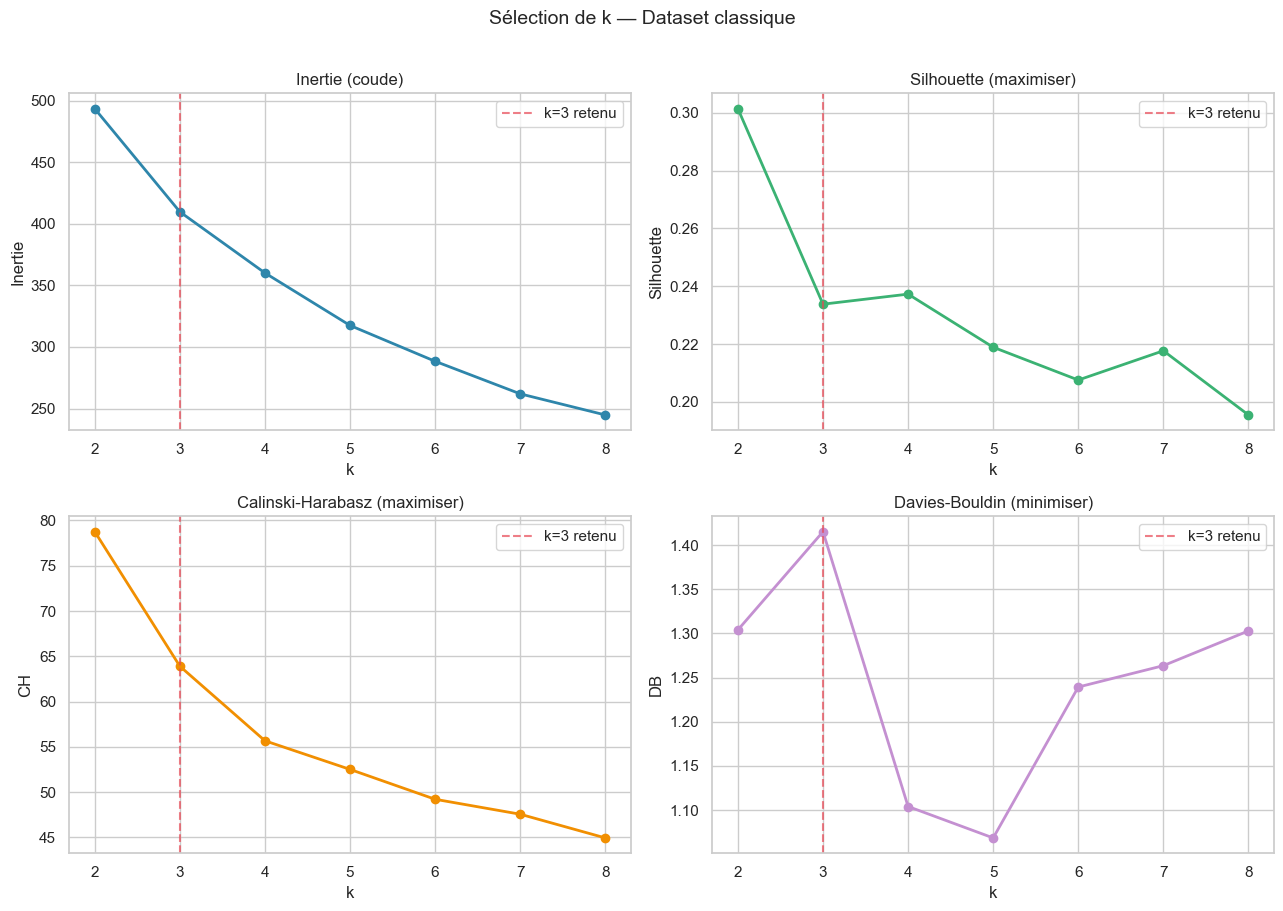

 k Inertie Delta Silhouette   CH     DB
 2   493.5     —     0.3014 78.8 1.3041
 3   409.7  83.7     0.2338 63.9 1.4153
 4   360.1  49.6     0.2373 55.7 1.1041
 5   317.4  42.6     0.2189 52.5 1.0685
 6   288.3  29.1     0.2075 49.2 1.2394
 7   261.9  26.4     0.2177 47.6 1.2636
 8   244.8  17.2     0.1955 44.9 1.3029


In [50]:
inertias_r, sils_r, chs_r, dbs_r = [], [], [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=SEED)
    lbl = km.fit_predict(X_raw)
    inertias_r.append(km.inertia_)
    sils_r.append(silhouette_score(X_raw, lbl))
    chs_r.append(calinski_harabasz_score(X_raw, lbl))
    dbs_r.append(davies_bouldin_score(X_raw, lbl))

k_vals = list(K_RANGE)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0,0].plot(k_vals, inertias_r, 'o-', color='#2E86AB', linewidth=2)
axes[0,0].axvline(3, color='#E84855', linestyle='--', alpha=0.7, label='k=3 retenu')
axes[0,0].set_title('Inertie (coude)'); axes[0,0].set_xlabel('k'); axes[0,0].set_ylabel('Inertie')
axes[0,0].legend()

axes[0,1].plot(k_vals, sils_r, 'o-', color='#3BB273', linewidth=2)
axes[0,1].axvline(3, color='#E84855', linestyle='--', alpha=0.7, label='k=3 retenu')
axes[0,1].set_title('Silhouette (maximiser)'); axes[0,1].set_xlabel('k'); axes[0,1].set_ylabel('Silhouette')
axes[0,1].legend()

axes[1,0].plot(k_vals, chs_r, 'o-', color='#F18F01', linewidth=2)
axes[1,0].axvline(3, color='#E84855', linestyle='--', alpha=0.7, label='k=3 retenu')
axes[1,0].set_title('Calinski-Harabasz (maximiser)'); axes[1,0].set_xlabel('k'); axes[1,0].set_ylabel('CH')
axes[1,0].legend()

axes[1,1].plot(k_vals, dbs_r, 'o-', color='#C490D1', linewidth=2)
axes[1,1].axvline(3, color='#E84855', linestyle='--', alpha=0.7, label='k=3 retenu')
axes[1,1].set_title('Davies-Bouldin (minimiser)'); axes[1,1].set_xlabel('k'); axes[1,1].set_ylabel('DB')
axes[1,1].legend()

plt.suptitle('Sélection de k — Dataset classique', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

deltas = [inertias_r[i-1]-inertias_r[i] for i in range(1,len(inertias_r))]
df_m = pd.DataFrame({'k': k_vals,
    'Inertie':     [f'{v:.1f}' for v in inertias_r],
    'Delta':       ['—'] + [f'{d:.1f}' for d in deltas],
    'Silhouette':  [f'{v:.4f}' for v in sils_r],
    'CH':          [f'{v:.1f}' for v in chs_r],
    'DB':          [f'{v:.4f}' for v in dbs_r],
})
print(df_m.to_string(index=False))

La table confirme la convergence des critères vers k=3. 

k=2 domine sur silhouette et CH, mais une partition binaire développé/non-développé n'offre pas de valeur opérationnelle pour une ONG qui doit différencier ses types d'intervention.

k=4 présente une anomalie critique : l'inspection du profilage révèle qu'un cluster isolé ne contient qu'un seul pays (Myanmar), dont les valeurs d'exports_log et imports_log sont extrêmes en raison de restrictions commerciales historiques. Un cluster singleton est statistiquement sans sens et humanitairement inexploitable. k=4 est donc écarté.

k=3 est retenu : il produit trois groupes d'effectifs suffisants (51, 73, 43 pays)(voir modele finale) avec une hiérarchie de développement interprétable et alignée avec la mission de l'ONG HELP.

### Profil de silhouette pour k=3

Là où les indices précédents offraient une moyenne globale, ce graphique expose la situation individuelle de chaque pays au sein de sa classe.

Son utilité est ici double : il permet de vérifier que le passage à trois clusters ne crée pas de groupes artificiels et d'identifier les pays dont le profil socio-économique est à la charnière de deux catégories.

### Interprétation du graphique

Le profil de silhouette repose sur le calcul d'un coefficient pour chaque observation, quantifiant l'adéquation d'un pays à son groupe en comparant deux notions :

* **La cohésion** : La proximité du pays avec les autres membres de son propre cluster.
* **La séparation** : La distance entre le pays et les membres du cluster voisin le plus proche.

Visuellement, le graphique se décompose ainsi :

* **Les blocs colorés** : Chaque bloc représente un cluster. Sa hauteur correspond au nombre de pays qu'il contient.
* **La longueur des pointes** : Plus une barre s'étire vers la droite (proche de 1), plus le pays est solidement ancré dans son profil de développement.
* **La ligne rouge pointillée** : Elle représente la silhouette moyenne . Un cluster dont la majorité des pays dépassent cette ligne est considéré comme structurellement robuste.
* **Les valeurs proches de zéro ou négatives** : Elles signalent des pays ambigus, dont les indicateurs (PIB, mortalité, inflation) les situent à la frontière entre deux groupes.

### Pourquoi cette analyse est-elle nécessaire ?

Un pays situé en bout de profil est un cas d'école pour son cluster, à l'inverse, un pays avec un score proche de 0 est un pays en transition, il nécessite une attention particulière, car ses besoins pourraient rapidement basculer vers ceux du groupe voisin.

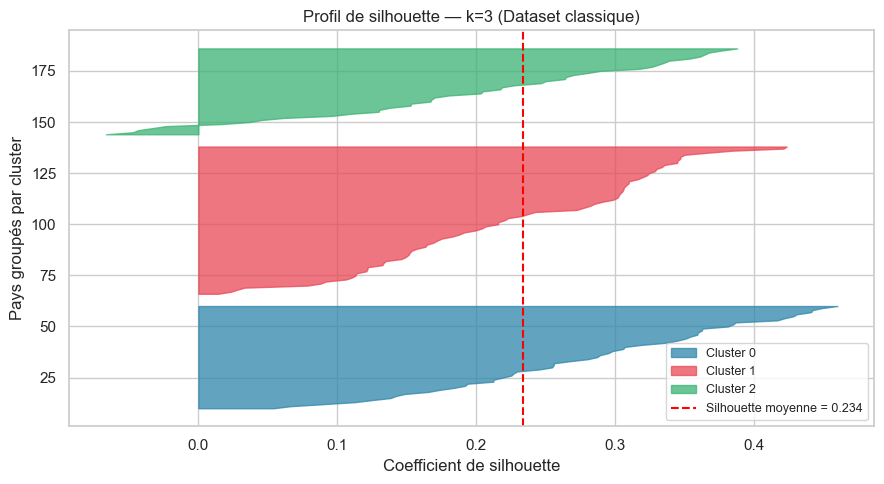

In [51]:
from sklearn.metrics import silhouette_samples

km3_sil = KMeans(n_clusters=3, init='k-means++', n_init=20, random_state=SEED)
lbl3_sil = km3_sil.fit_predict(X_raw)
sil_vals_r = silhouette_samples(X_raw, lbl3_sil)
avg_sil_r  = sil_vals_r.mean()

fig, ax = plt.subplots(figsize=(9, 5))
y_lower = 10
for cl in range(3):
    cl_sil = np.sort(sil_vals_r[lbl3_sil == cl])
    size = cl_sil.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cl_sil,
                     alpha=0.75, color=PALETTE[cl], label=f'Cluster {cl}')
    y_lower = y_upper + 5

ax.axvline(avg_sil_r, color='red', linestyle='--', linewidth=1.5,
           label=f'Silhouette moyenne = {avg_sil_r:.3f}')
ax.set_title('Profil de silhouette — k=3 (Dataset classique)')
ax.set_xlabel('Coefficient de silhouette')
ax.set_ylabel('Pays groupés par cluster')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

L'examen du profil de silhouette permet d'évaluer la cohérence de la partition à trois clusters en observant la qualité de l'affectation individuelle des pays. La structure globale apparaît saine, puisque chaque cluster dispose d'une proportion significative d'observations dépassant la silhouette moyenne . Le cluster 0 se distingue par la meilleure cohésion interne, avec des coefficients atteignant des valeurs proches de 0,45, ce qui dénote des profils de pays très homogènes et nettement différenciés des autres groupes.

Toutefois, le graphique révèle des fragilités locales, particulièrement au sein du cluster 2. Ce dernier présente une pointe négative, indiquant que certains pays ont été affectés à ce groupe alors qu'ils présentent plus de similitudes avec le cluster voisin le plus proche. Ces zones de faible silhouette, ainsi que les profils étroits observés à la base des clusters 1 et 2, signalent des pays en situation de transition dont les indicateurs socio-économiques sont à la lisière de deux catégories. Cette hétérogénéité souligne que, si la segmentation en trois niveaux est globalement robuste, l'intervention de l'ONG devra être nuancée pour les nations situées dans ces zones d'ambiguïté.

---

##  Dendrogramme 

L'analyse par K-means ayant permis de dégager une première structure, il convient désormais d'en éprouver la stabilité par une approche hiérarchique. Cette transition vers la Classification Ascendante Hiérarchique (CAH) permet de confronter la partition du K-Means à la généalogie structurelle des données, sans imposer de contrainte préalable sur le nombre de classes.

Le recours à la CAH, associée à la liaison de Ward, répond à trois objectifs méthodologiques précis :

* **Minimisation de l'inertie** : À l'instar du K-Means, la méthode de Ward vise à minimiser l'augmentation de la variance intra-classe à chaque étape de fusion.
* **Identification des sauts d'inertie** : La hauteur des arcs dans le dendrogramme traduit la perte d'homogénéité consécutive à un regroupement. Un saut brusque dans ces hauteurs indique une rupture naturelle, révélant ainsi le nombre optimal de clusters intrinsèque aux données.
* **Validation croisée** : En comparant les scores de silhouette de la CAH à ceux obtenus précédemment, nous confirmons si la structure à trois niveaux est une propriété robuste des données ou un simple artefact algorithmique.



Le clustering hiérarchique (CAH) avec la liaison de Ward complète l'analyse KMeans en offrant une lecture sans a priori sur $k$. Ward minimise l'augmentation de variance intra-cluster à chaque fusion. La hauteur des arcs dans le dendrogramme représente la dissimilarité entre les groupes fusionnés ; un saut brusque signale une rupture structurelle naturelle dans les données.

Noter que nous avons tester plusieurs methodes de linkages et que a chaque fois c'est ward qui resort avec les meilleurs scores de silhouette

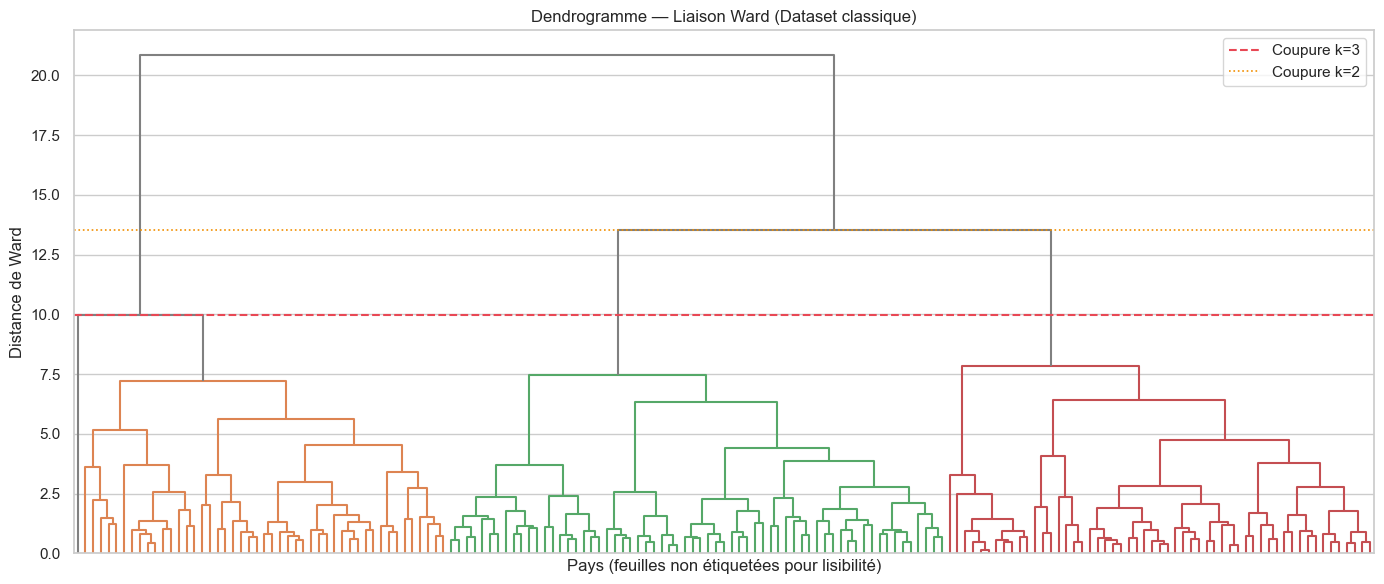

Scores de silhouette CAH Ward par k :
  k=2 : 0.3110
  k=3 : 0.2085
  k=4 : 0.2148
  k=5 : 0.1825


In [52]:
Z_r = linkage(X_raw, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z_r, ax=ax, no_labels=True,
           color_threshold=Z_r[-3, 2],
           above_threshold_color='gray', leaf_rotation=90)
ax.axhline(Z_r[-3, 2], color='#E84855', linestyle='--', linewidth=1.5, label='Coupure k=3')
ax.axhline(Z_r[-2, 2], color='#F18F01', linestyle=':', linewidth=1.2, label='Coupure k=2')
ax.set_title('Dendrogramme — Liaison Ward (Dataset classique)')
ax.set_xlabel('Pays (feuilles non étiquetées pour lisibilité)')
ax.set_ylabel('Distance de Ward')
ax.legend()
plt.tight_layout()
plt.show()

print('Scores de silhouette CAH Ward par k :')
for k in [2, 3, 4, 5]:
    lbl_cah = fcluster(Z_r, k, criterion='maxclust')
    sil = silhouette_score(X_raw, lbl_cah)
    print(f'  k={k} : {sil:.4f}')

L’ordonnée du dendrogramme traduit la distance de Ward, laquelle quantifie l'accroissement de l'inertie intra-classe résultant de la fusion de deux branches. Une hauteur d'arc élevée indique une forte hétérogénéité entre les groupes réunis, tandis que des fusions à bas niveau signalent des pays aux caractéristiques socio-économiques quasi identiques. L’interprétation structurelle de ce diagnostic repose sur l'observation des sauts de verticalité :

* **Structure hiérarchique** : la coupure à une distance de 13,5 (ligne pointillée orange) scinde la population en deux pôles majeurs, confirmant une polarisation nette des niveaux de développement à l'échelle mondiale.
* **Validation du choix de $k$** : la ligne discontinue rouge intercepte trois branches verticales distinctes. Le saut d'inertie prononcé au-dessus de ce seuil suggère que trois est un nombre de clusters naturel ; fusionner ces blocs entraînerait une dégradation brutale de la cohérence interne des groupes.

---

L'analyse des scores de silhouette pour cette approche hiérarchique précise le diagnostic :

| Nombre de clusters ($k$) | Score de silhouette |
| --- | --- |
| **$k=2$** | **$0,3110$** |
| **$k=3$** | **$0,2085$** |
| **$k=4$** | **$0,2148$** |
| **$k=5$** | **$0,1825$** |

Bien que la partition binaire maximise la silhouette, elle demeure trop pauvre pour les besoins opérationnels de l’ONG. Le score pour k=4 ($0,2148$) surpasse légèrement celui de $k=3$ ($0,2085$). Toutefois, le choix de $k=3$ constitue le compromis optimal. Si le graphique suggère des effectifs équilibrés pour $k=4$, cette partition repose sur une distance de Ward bien plus faible, traduisant une fragmentation de groupes déjà homogènes sans gain structurel majeur. 
>En privilégiant $k=3$, on garantit une stabilité entre les méthodes (K-Means et CAH) et une lisibilité métier indispensable à la segmentation stratégique des interventions de HELP International.

---

##  DBSCAN 

La transition vers un algorithme de partitionnement fondé sur la densité, tel que DBSCAN, permet d'appréhender la structure du jeu de données sous un angle géométrique différent. Contrairement aux approches précédentes qui supposent des formes convexes, cette méthode identifie des zones de forte concentration séparées par des régions de faible densité. Le choix des paramètres $\epsilon$ (rayon de voisinage) et $min\_samples$ (seuil de densité) est ici guidé par l'étude de la courbe de $k$-distance.

---





DBSCAN (Density-Based Spatial Clustering of Applications with Noise) contrairement à  KMEANS,il cherche des régions denses dans l'espace des données, séparées par des zones de faible densité. Son paramètre eps définit le rayon de voisinage, et min_samples définit le nombre minimal de points pour qu'un voisinage soit considéré comme dense .

L'application de DBSCAN ici n'a pas vocation à remplacer KMeans, mais à tester l'hypothèse de structure. Si les données contenaient des groupes à densité variable — par exemple, un noyau dense de pays très similaires entouré de pays plus dispersés — DBSCAN les détecterait mieux que KMeans, dont les frontières sphériques ne peuvent capturer des formes arbitraires.

La courbe de k-distance est l'outil standard pour estimer eps : on trie les pays par distance décroissante à leur k-ième plus proche voisin. Un coude net dans cette courbe indique le seuil naturel de densité. Son absence indique un continuum , les données ne s'organisent pas en îlots denses, ce qui justifie le recours à KMeans.

DBSCAN est appliqué ici comme diagnostic. Son objectif est de vérifier si les données présentent des groupes à densité variable ou des outliers denses qui remettraient en cause l'hypothèse sphérique de KMeans. La courbe de k-distance (distance au k-ième plus proche voisin, triée par ordre décroissant) permet d'estimer eps : l'inflexion indique le seuil naturel de densité.

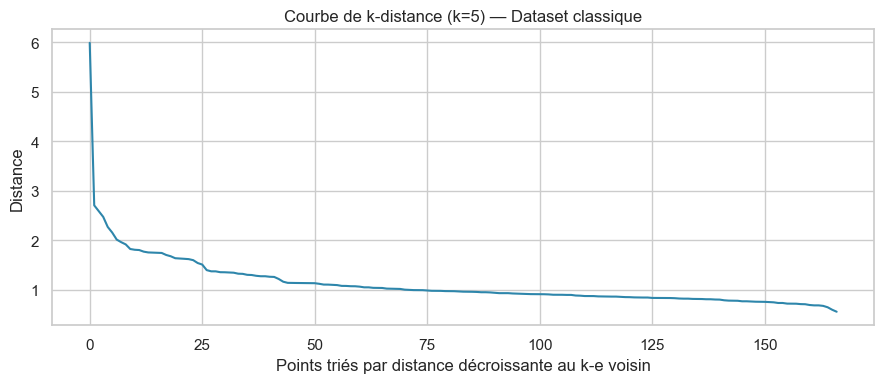

eps estimé (percentile 85 de la k-distance) : 1.509
  eps  min_s  n_clusters  bruit_%  silhouette
1.509      3           2      5.4      0.1635


In [53]:
k_nn = 5
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(X_raw)
distances, _ = nbrs.kneighbors(X_raw)
dist_sorted = np.sort(distances[:, k_nn-1])[::-1]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(dist_sorted, color='#2E86AB', linewidth=1.5)
ax.set_title(f'Courbe de k-distance (k={k_nn}) — Dataset classique')
ax.set_xlabel('Points triés par distance décroissante au k-e voisin')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()

eps_r = float(np.percentile(dist_sorted, 85))
print(f'eps estimé (percentile 85 de la k-distance) : {eps_r:.3f}')

step_r = max(0.05, eps_r * 0.15)
rows_db = []
for eps_try in np.arange(eps_r - step_r, eps_r + step_r * 2.5, step_r):
    for min_s in [3, 5, 7, 10, 12]:
        lbl = DBSCAN(eps=round(eps_try, 3), min_samples=min_s).fit_predict(X_raw)
        n_cl = len(set(lbl)) - (1 if -1 in lbl else 0)
        noise = (lbl == -1).mean()
        if n_cl >= 2 and noise < 0.30:
            sil = silhouette_score(X_raw, lbl)
            rows_db.append({'eps': round(eps_try, 3), 'min_s': min_s, 'n_clusters': n_cl,
                             'bruit_%': round(noise*100, 1), 'silhouette': round(sil, 4)})
if rows_db:
    print(pd.DataFrame(rows_db).sort_values('silhouette', ascending=False).head(10).to_string(index=False))
else:
    print('Aucune configuration DBSCAN valide (n_clusters>=2, bruit<30%) trouvée.')

La courbe de k-distance ne présente pas d'inflexion nette , elle décroît de façon continue sans coude marqué, ce qui indique que les données ne sont pas structurées en îlots à densité uniforme.

L'étude de la k-distance pour k=5 révèle une structure de densité hétérogène, marquée par une décroissance abrupte initiale traduisant l'isolement prononcé de quelques unités statistiques. Le point d'inflexion, ou « coude », se stabilise aux alentours de $1,5$, seuil identifié comme le rayon de voisinage $\epsilon$ optimal pour capturer les noyaux de forte concentration tout en écartant les observations les plus atypiques.

L'application de l'algorithme DBSCAN avec un paramètre $\epsilon = 1,509$ et un seuil de densité $min\_samples = 3$ aboutit à une partition en deux clusters, avec un taux de bruit résiduel de $5,4\%$. Bien que cette configuration parvienne à isoler les anomalies structurelles, le score de silhouette de $0,1635$ est sensiblement inférieur à ceux obtenus par les méthodes précédentes. Ce résultat confirme que les indicateurs de développement forment un continuum de densité plutôt que des groupes aux frontières géométriques nettes.Cette méthode est donc abandonnée ici.

## Modèle final : KMeans k=3

L'ensemble des diagnostics  ayant confirmé la supériorité et la stabilité du partitionnement par K-Means à trois groupes, ce modèle est désormais retenu comme cadre de référence . 

L'optimisation des hyperparamètres constitue l'étape logique suivant la validation du nombre de clusters. Pour l'algorithme K-Means, bien que $k$ soit le paramètre principal, la qualité de la convergence dépend de la stratégie d'initialisation et du nombre de lancements. En testant systématiquement les méthodes `k-means++` et `random`, ainsi qu'en augmentant le nombre d'itérations $n\_init$, nous nous assurons d'atteindre l'optimum global de l'inertie. Cette phase de réglage fin garantit que la partition retenue pour l'ONG est non seulement stable, mais aussi la plus performante mathématiquement pour segmenter les pays.

### Optimisation hyperparamétres : initialisations

Une fois le nombre de clusters fixé à $k=3$, l'étape suivante consiste à optimiser les hyperparamètres de l'algorithme pour garantir la convergence vers l'optimum global de l'inertie. En comparant les stratégies d'initialisation `k-means++` et `random` tout en augmentant le nombre de lancements ($n\_init$), nous nous assurons d'obtenir la partition la plus stable et performante.

In [54]:
K_FINAL_R = 3

print(f"{'init':12s}  {'temps(s)':>8s}  {'inertie':>10s}  {'Silhouette':>10s}  {'CH':>8s}  {'DB':>8s}")
for init_method in ['k-means++', 'random']:
    t0 = time()
    km_tmp = KMeans(n_clusters=K_FINAL_R, init=init_method, n_init=20, random_state=SEED)
    lbl_tmp = km_tmp.fit_predict(X_raw)
    elapsed = time() - t0
    print(f"{init_method:12s}  {elapsed:>8.3f}  {km_tmp.inertia_:>10.1f}  "
          f"{silhouette_score(X_raw, lbl_tmp):>10.4f}  "
          f"{calinski_harabasz_score(X_raw, lbl_tmp):>8.1f}  "
          f"{davies_bouldin_score(X_raw, lbl_tmp):>8.4f}")

init          temps(s)     inertie  Silhouette        CH        DB
k-means++        0.062       409.7      0.2338      63.9    1.4153
random           0.033       409.7      0.2338      63.9    1.4153


les deux méthodes d'init convergent

### Stabilité du partitionnement

Avant de figer la segmentation, il faut s'assurer que le modèle est insensible aux conditions initiales de l'algorithme. Le k-means étant dépendant du choix des centroïdes de départ, l'analyse de la stabilité par l'Indice de Rand Ajusté  permet de vérifier si la partition à trois clusters est une structure naturelle des données ou un simple résultat aléatoire.cette reproductibilité est le garant d'un ciblage équitable et rigoureux des interventions.

Le graphique synthétise cette analyse sur cent itérations :

* **Rôle de l'ARI** : cet indice mesure la similitude entre deux partitions. Un score de $1,0$ indique une concordance parfaite des affectations de pays.

* **Objectif visuel** : la courbe permet d'observer la variance de l'indice sur un grand nombre de graines aléatoires afin de confirmer que l'algorithme converge systématiquement vers une solution identique.
* **Interprétation du seuil** : le maintien des scores au-dessus d'un seuil élevé (généralement $0,90$) atteste que les frontières entre les clusters ne sont pas des artefacts du hasard, mais des réalités statistiques robustes.


ARI moyen   : 0.9562
ARI minimum : 0.7962
ARI std     : 0.0302


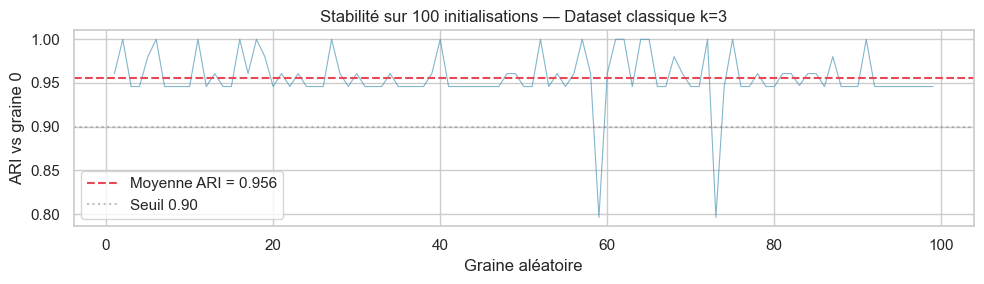

In [55]:
lbls_r = [KMeans(n_clusters=K_FINAL_R, random_state=s, n_init=10).fit_predict(X_raw) for s in range(N_RUNS)]
aris_r = [adjusted_rand_score(lbls_r[0], lbls_r[i]) for i in range(1, N_RUNS)]

print(f'ARI moyen   : {np.mean(aris_r):.4f}')
print(f'ARI minimum : {np.min(aris_r):.4f}')
print(f'ARI std     : {np.std(aris_r):.4f}')

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(range(1, N_RUNS), aris_r, alpha=0.6, linewidth=0.8, color='#2E86AB')
ax.axhline(np.mean(aris_r), color='#E84855', linestyle='--', linewidth=1.5,
           label=f'Moyenne ARI = {np.mean(aris_r):.3f}')
ax.axhline(0.9, color='gray', linestyle=':', alpha=0.5, label='Seuil 0.90')
ax.set_xlabel('Graine aléatoire'); ax.set_ylabel('ARI vs graine 0')
ax.set_title('Stabilité sur 100 initialisations — Dataset classique k=3')
ax.legend(); plt.tight_layout(); plt.show()

Les résultats attestent d'une stabilité remarquable de la partition. Le graphique  montre que la quasi-totalité des itérations se maintient largement au-dessus du seuil de 0,90. Bien que deux chutes ponctuelles soient visibles vers 0,80, la concentration massive des scores autour de la moyenne de 0,956 prouve que la structure à trois clusters est une propriété fondamentale du jeu de données, et non un artefact lié au hasard de l'initialisation.

In [56]:
km_r     = KMeans(n_clusters=K_FINAL_R, init='k-means++', n_init=20, random_state=SEED)
labels_r = km_r.fit_predict(X_raw)
df_cl_r  = df_raw.copy()
df_cl_r['cluster'] = labels_r

print('Répartition :')
print(df_cl_r['cluster'].value_counts().sort_index())
print(f'Silhouette : {silhouette_score(X_raw, labels_r):.4f}')
print(f'CH         : {calinski_harabasz_score(X_raw, labels_r):.1f}')
print(f'DB         : {davies_bouldin_score(X_raw, labels_r):.4f}')

Répartition :
cluster
0    51
1    73
2    43
Name: count, dtype: int64
Silhouette : 0.2338
CH         : 63.9
DB         : 1.4153


## Visualisations 2D

### Projection PCA

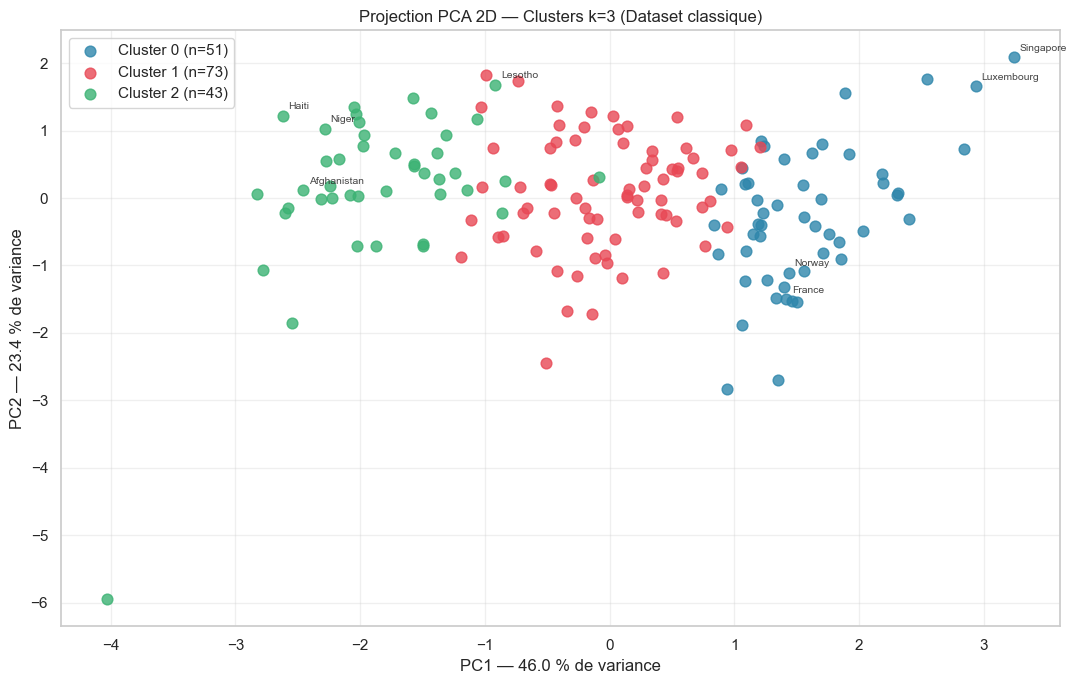

In [57]:
pca2_r   = PCA(n_components=2, random_state=SEED).fit(X_raw)
X_pca2_r = pca2_r.transform(X_raw)

df_viz_r = pd.DataFrame(X_pca2_r, columns=['PC1','PC2'])
df_viz_r['cluster'] = labels_r
df_viz_r['country'] = df_raw['country'].values

LABEL_COUNTRIES = ['United States of America', 'Afghanistan', 'Niger', 'France',
                   'Somalia', 'Norway', 'Haiti', 'Lesotho', 'Luxembourg', 'Singapore']

fig, ax = plt.subplots(figsize=(11, 7))
for cl in sorted(df_viz_r['cluster'].unique()):
    sub = df_viz_r[df_viz_r['cluster'] == cl]
    ax.scatter(sub['PC1'], sub['PC2'], s=60, alpha=0.8, color=PALETTE[cl],
               label=f'Cluster {cl} (n={len(sub)})', zorder=3)
    for _, row in sub.iterrows():
        if row['country'] in LABEL_COUNTRIES:
            ax.annotate(row['country'], (row['PC1'], row['PC2']),
                        fontsize=7.5, alpha=0.85, ha='left', va='bottom',
                        xytext=(4, 3), textcoords='offset points')

ax.set_xlabel(f'PC1 — {pca_r.explained_variance_ratio_[0]*100:.1f} % de variance')
ax.set_ylabel(f'PC2 — {pca_r.explained_variance_ratio_[1]*100:.1f} % de variance')
ax.set_title('Projection PCA 2D — Clusters k=3 (Dataset classique)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

La projection PCA 2D organise les 167 pays selon le gradient de développement capturé par PC1. Les pays développés (cluster 0 : États-Unis, France, Norvège, Singapour) se concentrent dans la partie positive de PC1, tandis que les pays en difficulté humanitaire (cluster 2 : Afghanistan, Niger, Somalie) occupent la partie negative. Le cluster 1 (intermédiaires) occupe la zone médiane, avec un étalement naturel qui traduit l'hétérogénéité de cette catégorie. L'axe PC2 introduit une dispersion orthogonale liée aux échanges commerciaux : des pays comme le Luxembourg ou Singapour s'écartent verticalement en raison de leur forte ouverture commerciale, sans pour autant sortir du cluster des développés.

 La projection est indicative — les zones de chevauchement visibles entre clusters 1 et 2 ne signifient pas une mauvaise partition : elles résultent de la réduction de dimension, les deux axes ne capturant que 69 % de la variance. La séparation complète existe dans l'espace à 8 dimensions où le clustering a été réalisé.

### Projection t-SNE

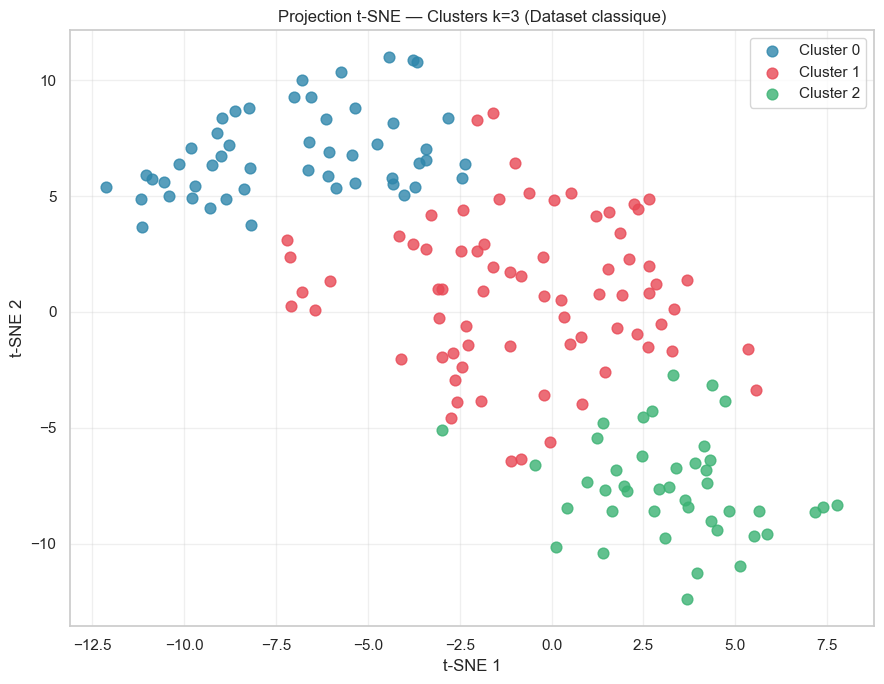

In [58]:
tsne_r   = TSNE(n_components=2, random_state=SEED, perplexity=30, metric='euclidean')
X_tsne_r = tsne_r.fit_transform(X_raw)

df_tsne_r = pd.DataFrame(X_tsne_r, columns=['t1','t2'])
df_tsne_r['cluster'] = labels_r

fig, ax = plt.subplots(figsize=(9, 7))
for cl in sorted(df_tsne_r['cluster'].unique()):
    sub = df_tsne_r[df_tsne_r['cluster'] == cl]
    ax.scatter(sub['t1'], sub['t2'], s=60, alpha=0.8, color=PALETTE[cl],
               label=f'Cluster {cl}', zorder=3)
ax.set_title('Projection t-SNE — Clusters k=3 (Dataset classique)')
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

La projection t-SNE, qui préserve les relations de voisinage locales dans l'espace , confirme l'existence de trois nuages distincts. La forme allongée de certains clusters est cohérente avec la nature continue des gradients de développement : les pays ne s'organisent pas en îlots isolés mais en segments d'un continuum, ce que KMeans partitionne par hyperplans dans l'espace euclidien normalisé.

##  Profilage des clusters

In [59]:
profile_r = df_cl_r.groupby('cluster')[num_cols_r].mean().round(3)
print('Profil moyen par cluster :')
print(profile_r.to_string())
print()
print('Effectifs :')
print(df_cl_r['cluster'].value_counts().sort_index())

Profil moyen par cluster :
         life_expec  child_mort_log  total_fer  gdpp_log  health  inflation_log  exports_log  imports_log
cluster                                                                                                  
0            78.676           1.911      1.709    10.026   8.857          0.681        3.864        3.910
1            71.473           3.179      2.619     8.483   5.502          2.187        3.672        3.716
2            59.367           4.484      4.976     6.720   6.624          2.124        2.984        3.605

Effectifs :
cluster
0    51
1    73
2    43
Name: count, dtype: int64


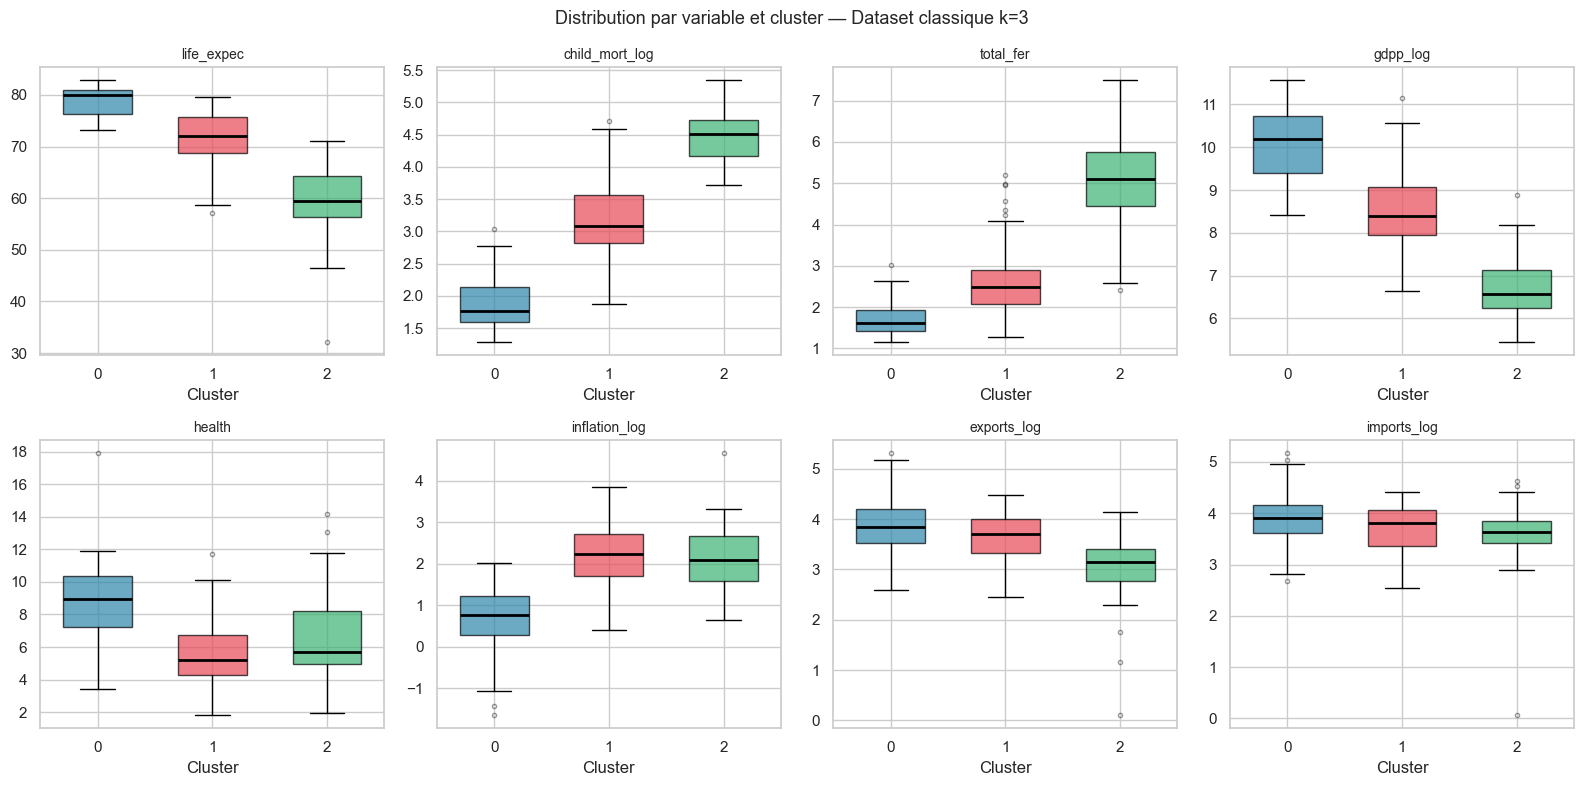

In [60]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols_r):
    ax = axes[i]
    for cl in sorted(df_cl_r['cluster'].unique()):
        data = df_cl_r[df_cl_r['cluster'] == cl][col]
        ax.boxplot(data, positions=[cl], widths=0.6, patch_artist=True,
                   boxprops=dict(facecolor=PALETTE[cl], alpha=0.7),
                   medianprops=dict(color='black', linewidth=2),
                   flierprops=dict(marker='o', markersize=3, alpha=0.4))
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('Cluster')
    ax.set_xticks([0, 1, 2])

plt.suptitle('Distribution par variable et cluster — Dataset classique k=3', fontsize=13)
plt.tight_layout(); plt.show()

Le profilage révèle trois niveaux de développement distincts et cohérents. Le cluster 0 rassemble les pays à fort développement humain (life_expec ≈ 79 ans, child_mort_log faible, gdpp_log ≈ 10) — ce sont les pays auxquels l'ONG HELP n'a pas vocation à s'adresser. Le cluster 1 constitue le groupe intermédiaire ou en transition (life_expec ≈ 71 ans, gdpp_log ≈ 8.5) — des interventions de soutien au développement sont pertinentes. Le cluster 2 identifie les pays en difficulté structurelle (life_expec ≈ 59 ans, child_mort_log élevé, gdpp_log ≈ 6.7, fécondité élevée) — ce sont les priorités d'intervention humanitaire d'urgence.

In [61]:
for cl, label in {0: 'développés', 1: 'intermédiaires', 2: 'priorité humanitaire'}.items():
    pays = df_cl_r[df_cl_r['cluster'] == cl]['country'].sort_values().tolist()
    print(f'Cluster {cl} — {label} (n={len(pays)}) :')
    print('  ', pays[:15], '...' if len(pays) > 15 else '')
    print()

Cluster 0 — développés (n=51) :
   ['Antigua and Barbuda', 'Australia', 'Austria', 'Bahamas', 'Barbados', 'Belgium', 'Bosnia and Herzegovina', 'Bulgaria', 'Canada', 'Costa Rica', 'Croatia', 'Cyprus', 'Czech Republic', 'Denmark', 'Estonia'] ...

Cluster 1 — intermédiaires (n=73) :
   ['Albania', 'Algeria', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Belarus', 'Belize', 'Bhutan', 'Bolivia', 'Botswana', 'Brazil', 'Brunei', 'Cambodia'] ...

Cluster 2 — priorité humanitaire (n=43) :
   ['Afghanistan', 'Angola', 'Benin', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', "Cote d'Ivoire", 'Eritrea', 'Gambia', 'Ghana', 'Guinea'] ...



##  Carte géographique

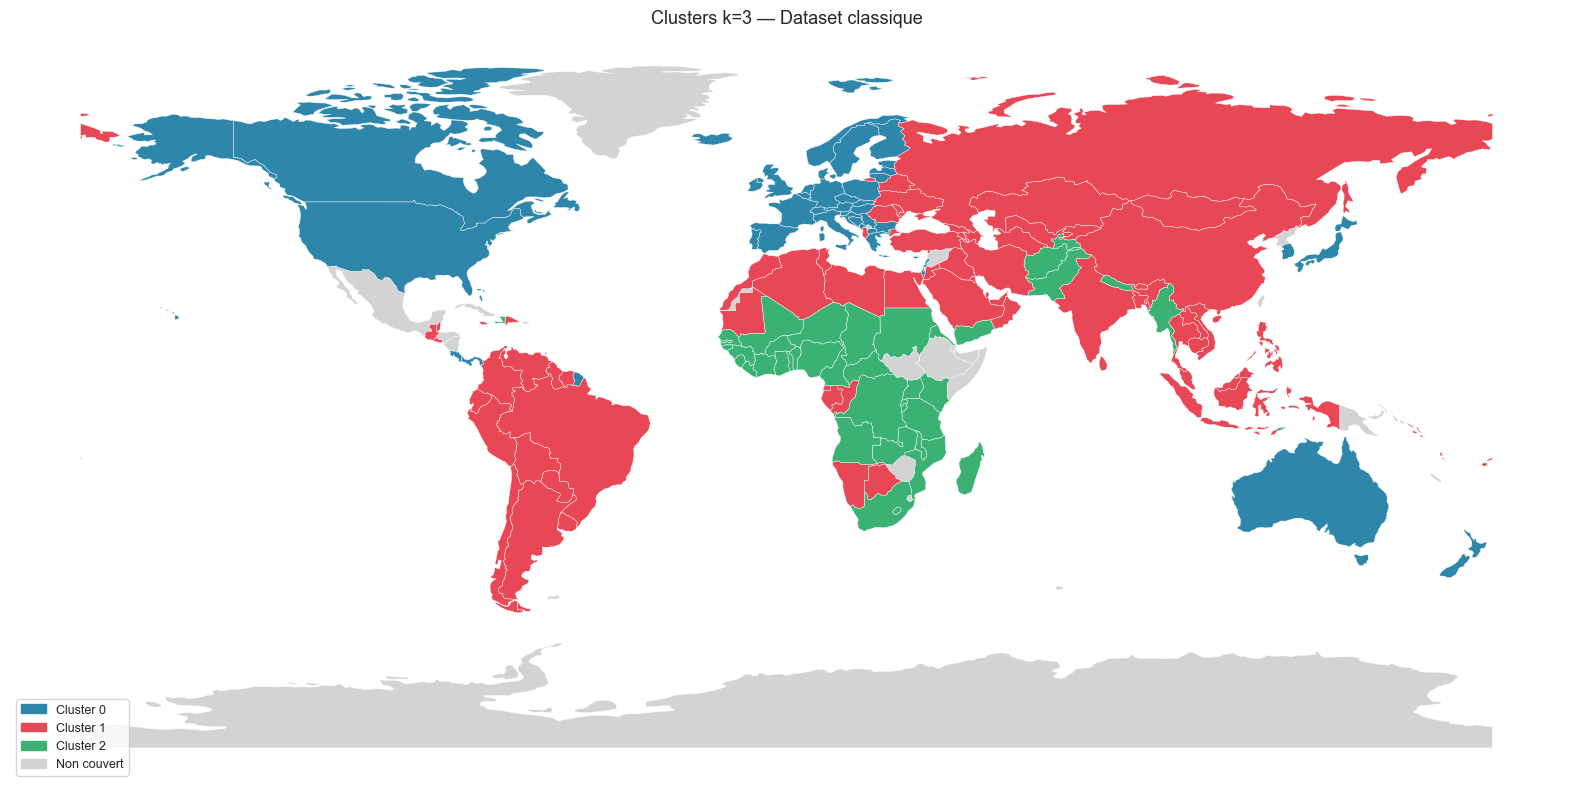

In [62]:
df_map_r = df_cl_r[['country', 'cluster']].copy()
df_map_r['country'] = apply_ne_mapping(df_map_r['country'], dataset='classic')

world_r = world.merge(df_map_r, left_on='ADMIN', right_on='country', how='left')

fig, ax = plt.subplots(figsize=(16, 8))
world_r[world_r['cluster'].isna()].plot(ax=ax, color='#D3D3D3', edgecolor='white', linewidth=0.3)
for cl in sorted(df_map_r['cluster'].dropna().unique()):
    world_r[world_r['cluster'] == cl].plot(ax=ax, color=PALETTE[int(cl)],
                                            edgecolor='white', linewidth=0.3)
patches = [mpatches.Patch(color=PALETTE[c], label=f'Cluster {c}') for c in range(K_FINAL_R)]
patches.append(mpatches.Patch(color='#D3D3D3', label='Non couvert'))
ax.legend(handles=patches, loc='lower left', fontsize=9)
ax.set_title('Clusters k=3 — Dataset classique', fontsize=13)
ax.axis('off'); plt.tight_layout(); plt.show()

La carte confirme la cohérence géographique  le cluster 0 (développé) couvre Europe de l'Ouest, Amérique du Nord, Australasie et Japon. Le cluster 1 (intermédiaire) recouvre l'Amérique latine, l'Asie du Sud-Est, le Moyen-Orient et certains pays d'Europe de l'Est. Le cluster 2 (difficulté humanitaire) se concentre en Afrique subsaharienne et dans quelques pays d'Asie du Sud .

---
# Partie II : dataset enrichi multi-source 

Le dataset enrichi intègre des dimensions complémentaires absentes du dataset classique, issues de trois blocs thématiques : santé étendue (prévalence VIH, densité médicale, couverture vaccinale), vulnérabilité sociale (sous-alimentation, pauvreté extrême, scolarisation), et fragilité étatique (Fragile States Index 2015 : appareil sécuritaire, griefs de groupe, réfugiés/déplacés, intervention extérieure). Ces 14 variables permettent de discriminer des profils de vulnérabilité que les 8 variables classiques ne peuvent pas séparer  en particulier la crise sanitaire liée au VIH et la fragilité institutionnelle dues aux conflits.

##  Mise à l'échelle

In [63]:
scaler_e = RobustScaler()
X_enrich = scaler_e.fit_transform(df_enrich[num_cols_e])

print(f'Matrice : {X_enrich.shape[0]} pays × {X_enrich.shape[1]} variables')
print(f'NaN post-scaling : {np.isnan(X_enrich).sum()}')

Matrice : 167 pays × 14 variables
NaN post-scaling : 0


##  ACP — Dataset enrichi

L'ACP du dataset enrichi  suit la même logique diagnostique que pour le classique, mais avec un espace de départ de dimension plus élevée. L'intérêt principal est de vérifier si les nouvelles variables FSI et épidémiologiques apportent effectivement une information orthogonale aux 8 variables classiques, ou si elles sont redondantes.

Si PC1 concentre encore plus de variance que dans le classique (signe de cohérence thématique) et si PC2 capture des axes nouveaux absents du dataset classique (notamment la prévalence VIH et les indicateurs FSI), alors l'enrichissement est justifié donc il ajoute de l'information sans diluer la structure existante.

Le cercle de corrélation sur 14 variables est particulièrement révélateur : en regardant les angles entre les flèches FSI et les flèches socio-économiques classiques, on peut mesurer visuellement l'orthogonalité des nouvelles dimensions — et donc leur valeur ajoutée pour discriminer des sous-groupes que les 8 variables classiques confondaient.

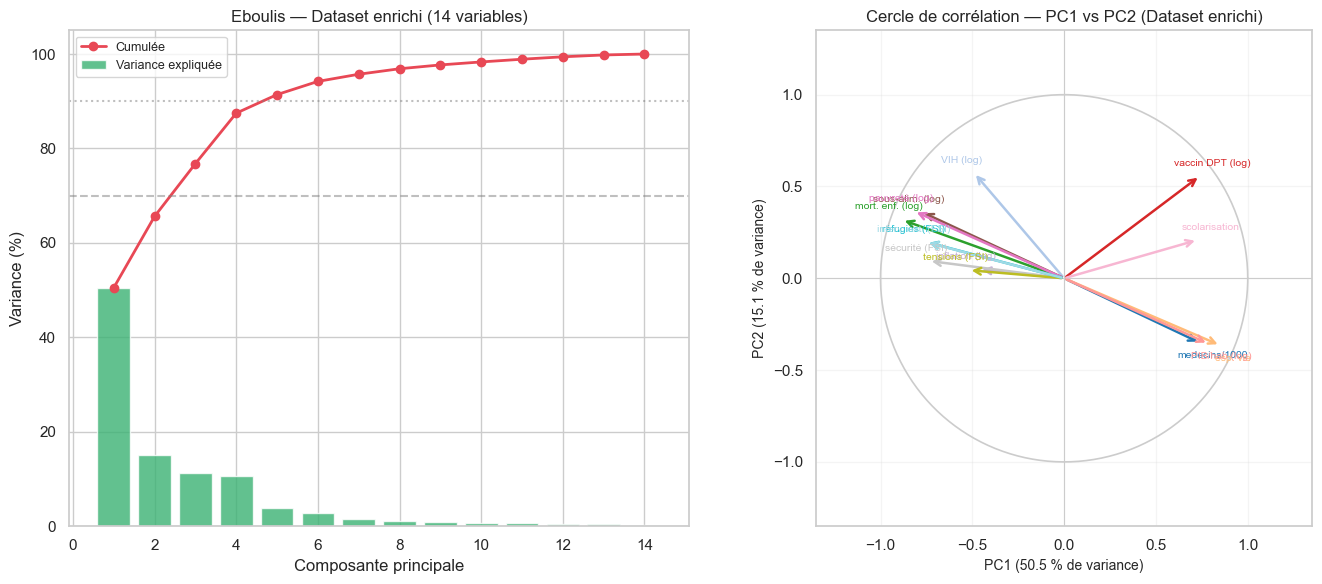

PC1 : 50.5%  |  PC2 : 15.1%  |  cumulé : 65.6%
PC1+PC2+PC3 : 76.8%
90 % atteint à PC5

Corrélations variables → PC1/PC2 (qualité = part expliquée par les 2 axes) :
                               PC1    PC2  qualite
child_mort_log              -0.883  0.319    0.881
vaccination_dpt_log          0.740  0.557    0.857
life_expec                   0.850 -0.365    0.856
social_poverty_2_15_log     -0.817  0.366    0.801
gdpp_log                     0.786 -0.356    0.744
social_undernourishment_log -0.776  0.361    0.733
physicians_per_1000          0.741 -0.352    0.672
external_intervention       -0.751  0.197    0.603
refugees_idps               -0.751  0.198    0.602
social_schooling_log         0.727  0.209    0.573
hiv_prevalence_log          -0.491  0.574    0.570
security_apparatus          -0.736  0.094    0.551
group_grievance             -0.519  0.044    0.272
inflation_log               -0.463  0.047    0.216


In [64]:
pca_e = PCA(random_state=SEED)
pca_e.fit(X_enrich)

var_exp_e = pca_e.explained_variance_ratio_
cum_var_e = np.cumsum(var_exp_e)

# Coordonnées du cercle de corrélation pour le dataset enrichi
X_pca_full_e = pca_e.transform(X_enrich)
n_feat_e     = len(num_cols_e)
corr_mat_e   = np.corrcoef(X_enrich.T, X_pca_full_e.T)
coords_cc_e  = corr_mat_e[:n_feat_e, n_feat_e:n_feat_e + 2]   # (n_feat, 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ─ Eboulis ──────────────────────────────────────────────────────────────────
axes[0].bar(range(1, len(var_exp_e)+1), var_exp_e * 100, color='#3BB273', alpha=0.8,
            label='Variance expliquée')
axes[0].plot(range(1, len(cum_var_e)+1), cum_var_e * 100, 'o-', color='#E84855',
             linewidth=2, label='Cumulée')
axes[0].axhline(70, color='gray', linestyle='--', alpha=0.5)
axes[0].axhline(90, color='gray', linestyle=':', alpha=0.5)
axes[0].set_xlabel('Composante principale')
axes[0].set_ylabel('Variance (%)')
axes[0].set_title('Eboulis — Dataset enrichi (14 variables)')
axes[0].legend(fontsize=9)

# ─ Cercle de corrélation ────────────────────────────────────────────────────
theta = np.linspace(0, 2 * np.pi, 300)
axes[1].plot(np.cos(theta), np.sin(theta), color='#CCCCCC', linewidth=1.2, zorder=1)
axes[1].axhline(0, color='#CCCCCC', linewidth=0.8, zorder=1)
axes[1].axvline(0, color='#CCCCCC', linewidth=0.8, zorder=1)

colors_cce = plt.cm.tab20(np.linspace(0, 1, n_feat_e))
short_labels = {
    'physicians_per_1000':         'medecins/1000',
    'hiv_prevalence_log':          'VIH (log)',
    'life_expec':                  'esp. vie',
    'child_mort_log':              'mort. enf. (log)',
    'vaccination_dpt_log':         'vaccin DPT (log)',
    'gdpp_log':                    'PIB/hab (log)',
    'inflation_log':               'inflation (log)',
    'social_undernourishment_log': 'sous-alim. (log)',
    'social_poverty_2_15_log':     'pauvreté (log)',
    'social_schooling_log':        'scolarisation',
    'security_apparatus':          'sécurité (FSI)',
    'group_grievance':             'tensions (FSI)',
    'refugees_idps':               'réfugiés (FSI)',
    'external_intervention':       'interv. ext. (FSI)',
}

for j, var in enumerate(num_cols_e):
    xc, yc = coords_cc_e[j, 0], coords_cc_e[j, 1]
    axes[1].annotate('', xy=(xc, yc), xytext=(0, 0),
                     arrowprops=dict(arrowstyle='->', color=colors_cce[j], lw=1.8),
                     zorder=3)
    offset_x = 0.07 if xc >= 0 else -0.07
    offset_y = 0.07 if yc >= 0 else -0.07
    axes[1].text(xc + offset_x, yc + offset_y, short_labels.get(var, var),
                 fontsize=7.5, color=colors_cce[j], ha='center', va='center', zorder=4)

axes[1].set_xlim(-1.35, 1.35)
axes[1].set_ylim(-1.35, 1.35)
axes[1].set_aspect('equal')
axes[1].set_xlabel(f'PC1 ({var_exp_e[0]*100:.1f} % de variance)', fontsize=10)
axes[1].set_ylabel(f'PC2 ({var_exp_e[1]*100:.1f} % de variance)', fontsize=10)
axes[1].set_title('Cercle de corrélation — PC1 vs PC2 (Dataset enrichi)')
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print(f'PC1 : {var_exp_e[0]*100:.1f}%  |  PC2 : {var_exp_e[1]*100:.1f}%  |  cumulé : {cum_var_e[1]*100:.1f}%')
print(f'PC1+PC2+PC3 : {cum_var_e[2]*100:.1f}%')
print(f'90 % atteint à PC{(cum_var_e>=0.90).argmax()+1}')

df_cc_e = pd.DataFrame(coords_cc_e.round(3), index=num_cols_e, columns=['PC1','PC2'])
df_cc_e['qualite'] = (coords_cc_e**2).sum(axis=1).round(3)
print('\nCorrélations variables → PC1/PC2 (qualité = part expliquée par les 2 axes) :')
print(df_cc_e.sort_values('qualite', ascending=False).to_string())

Sur le cercle de corrélation , deux directions antagonistes dominent PC1, qui concentre ≈ 50 % de la variance totale — un taux plus élevé que pour le classique (46 %), ce qui traduit la forte cohérence thématique des variables sélectionnées.

PC1 synthétise un gradient de richesse et de santé : gdpp_log, physicians_per_1000, social_schooling_log et vaccination_dpt_log forment un faisceau pointant dans une même direction (pôle développé), directement opposé à child_mort_log, social_poverty_2_15_log, social_undernourishment_log et security_apparatus (pôle vulnérable). Les flèches proches les unes des autres confirment la forte intercorrélation de ces indicateurs déjà observée dans la matrice de corrélation de P1.

PC2 (≈ 15 % de variance) capture une dimension orthogonale qui n'a pas d'équivalent dans le dataset classique. Les flèches de hiv_prevalence_log,vaccination_dpt_log  etc. dans une moindre mesure, refugees_idps se démarquent des autres variables sur cet axe. 

Leur orthogonalité par rapport aux indicateurs socio-économiques classiques (gdpp_log, life_expec) révèle que la prévalence VIH et les déplacements de populations sont partiellement indépendants du niveau de revenu donc il existe des pays relativement pauvres sans crise VIH majeure, et des pays à prévalence VIH élevée qui ne sont pas en situation de conflit armé actif. C'est précisément cette dimension que k=4 exploitera pour séparer deux formes de vulnérabilité que k=3 confondrait.

La qualité de représentation (cos2 sur PC1+PC2) est particulièrement bonne pour gdpp_log, child_mort_log et physicians_per_1000. Elle est plus faible pour inflation_log, qui mobilise des composantes supplémentaires ,signe que la dynamique inflationniste ne s'inscrit pas dans le gradient développement/vulnérabilité capturé par PC1.

##  Sélection du nombre de clusters k

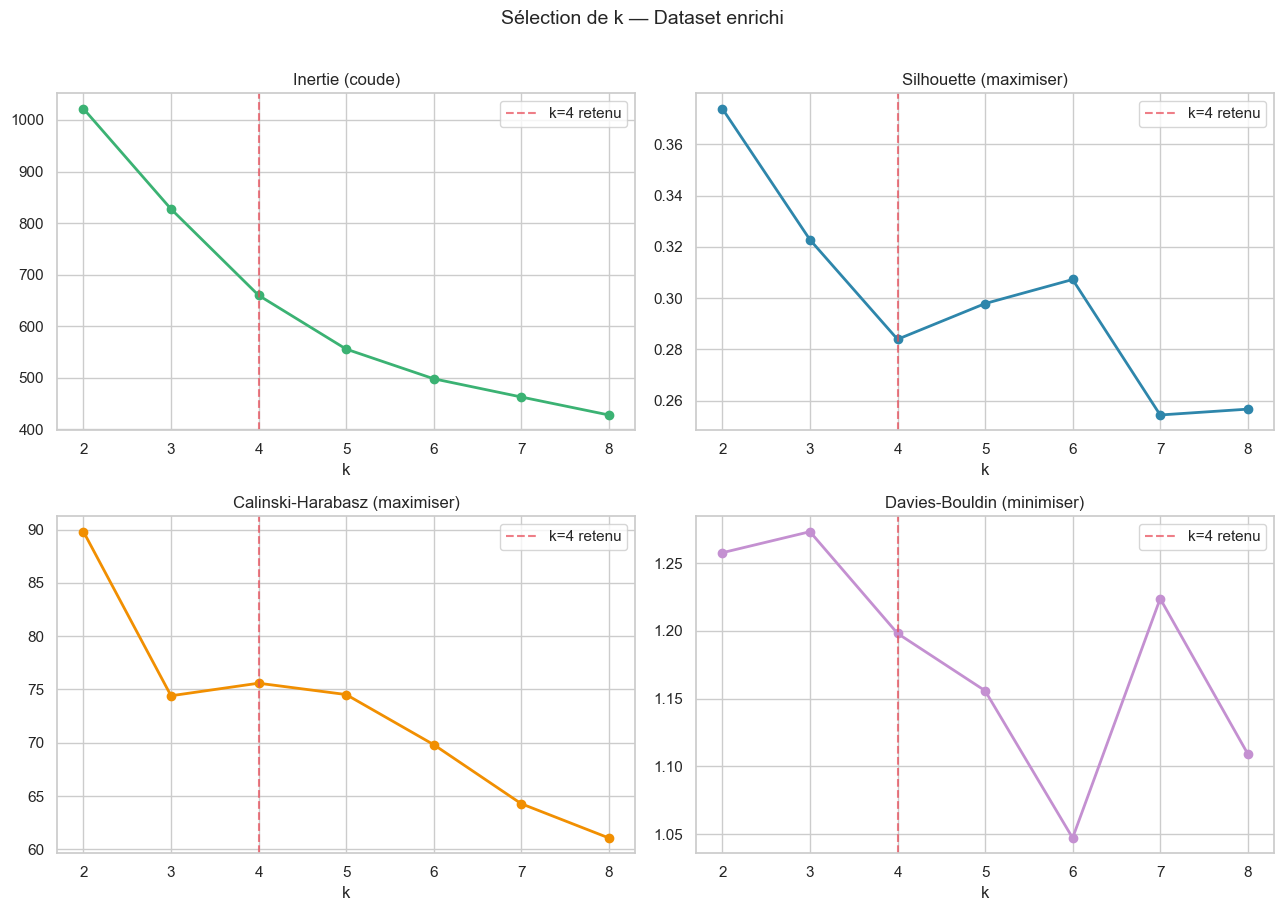

 k Inertie Delta Silhouette   CH     DB
 2  1021.8     —     0.3738 89.8 1.2577
 3   827.3 194.5     0.3228 74.4 1.2732
 4   659.9 167.4     0.2840 75.6 1.1982
 5   555.6 104.3     0.2979 74.5 1.1559
 6   498.0  57.6     0.3073 69.8 1.0473
 7   462.7  35.3     0.2545 64.3 1.2238
 8   427.8  34.9     0.2568 61.1 1.1093


In [65]:
inertias_e, sils_e, chs_e, dbs_e = [], [], [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=SEED)
    lbl = km.fit_predict(X_enrich)
    inertias_e.append(km.inertia_)
    sils_e.append(silhouette_score(X_enrich, lbl))
    chs_e.append(calinski_harabasz_score(X_enrich, lbl))
    dbs_e.append(davies_bouldin_score(X_enrich, lbl))

k_vals = list(K_RANGE)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0,0].plot(k_vals, inertias_e, 'o-', color='#3BB273', linewidth=2)
axes[0,0].axvline(4, color='#E84855', linestyle='--', alpha=0.7, label='k=4 retenu')
axes[0,0].set_title('Inertie (coude)'); axes[0,0].set_xlabel('k'); axes[0,0].legend()

axes[0,1].plot(k_vals, sils_e, 'o-', color='#2E86AB', linewidth=2)
axes[0,1].axvline(4, color='#E84855', linestyle='--', alpha=0.7, label='k=4 retenu')
axes[0,1].set_title('Silhouette (maximiser)'); axes[0,1].set_xlabel('k'); axes[0,1].legend()

axes[1,0].plot(k_vals, chs_e, 'o-', color='#F18F01', linewidth=2)
axes[1,0].axvline(4, color='#E84855', linestyle='--', alpha=0.7, label='k=4 retenu')
axes[1,0].set_title('Calinski-Harabasz (maximiser)'); axes[1,0].set_xlabel('k'); axes[1,0].legend()

axes[1,1].plot(k_vals, dbs_e, 'o-', color='#C490D1', linewidth=2)
axes[1,1].axvline(4, color='#E84855', linestyle='--', alpha=0.7, label='k=4 retenu')
axes[1,1].set_title('Davies-Bouldin (minimiser)'); axes[1,1].set_xlabel('k'); axes[1,1].legend()

plt.suptitle('Sélection de k — Dataset enrichi', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

deltas_e = [inertias_e[i-1]-inertias_e[i] for i in range(1,len(inertias_e))]
df_me = pd.DataFrame({'k': k_vals,
    'Inertie':     [f'{v:.1f}' for v in inertias_e],
    'Delta':       ['—'] + [f'{d:.1f}' for d in deltas_e],
    'Silhouette':  [f'{v:.4f}' for v in sils_e],
    'CH':          [f'{v:.1f}' for v in chs_e],
    'DB':          [f'{v:.4f}' for v in dbs_e],
})
print(df_me.to_string(index=False))

Les métriques sont plus nuancées pour le dataset enrichi. k=2 domine toujours mécaniquement. Au-delà, k=4 ressort comme le meilleur compromis : il affiche le CH le plus élevé parmi k ≥ 3 (75.6, contre 74.4 pour k=3 et 74.5 pour k=5) .

Mais l'argument le plus décisif est humanitaire. L'inspection du profilage à k=4 révèle que ce partitionnement sépare deux populations que k=3 confond dans un même cluster "vulnérable" :

[voir la suite] Les pays du cluster VIH (n ≈ 23, principalement Afrique subsaharienne orientale et australe) présentent une hiv_prevalence_log ≈ 1.83, soit une prévalence brute d'environ 6 fois supérieure à celle des autres clusters en difficulté. L'intervention humanitaire appropriée y est sanitaire (prévention, dépistage) et ne ressemble en rien à celle requise pour les pays du cluster conflit.

Les pays du cluster fragilité/conflit (n ≈ 22, Afghanistan, RDC, Centrafrique, Tchad...) présentent un security_apparatus FSI ≈ 8.4 et un group_grievance ≈ 7.9 — profil de délitement institutionnel et de violence structurelle. L'intervention y relève de l'aide d'urgence, de la protection des civils et de la stabilisation.

k=4 est retenu pour le dataset enrichi. k=5 créerait un micro-cluster de 7 pays avec un bénéfice marginal en CH et une perte en interprétabilité.

### Profil de silhouette k=4

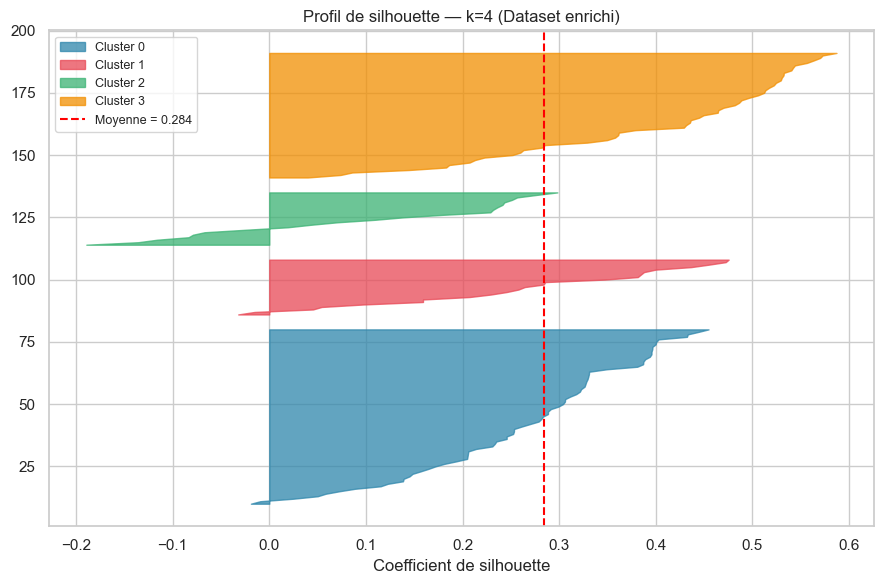

In [66]:
km4_sil = KMeans(n_clusters=4, init='k-means++', n_init=20, random_state=SEED)
lbl4_sil = km4_sil.fit_predict(X_enrich)
from sklearn.metrics import silhouette_samples
sil_vals_e = silhouette_samples(X_enrich, lbl4_sil)
avg_sil_e  = sil_vals_e.mean()

fig, ax = plt.subplots(figsize=(9, 6))
y_lower = 10
for cl in range(4):
    cl_sil = np.sort(sil_vals_e[lbl4_sil == cl])
    size = cl_sil.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cl_sil, alpha=0.75, color=PALETTE[cl], label=f'Cluster {cl}')
    y_lower = y_upper + 5
ax.axvline(avg_sil_e, color='red', linestyle='--', linewidth=1.5, label=f'Moyenne = {avg_sil_e:.3f}')
ax.set_title('Profil de silhouette — k=4 (Dataset enrichi)')
ax.set_xlabel('Coefficient de silhouette'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

L'analyse détaillée du profil de silhouette , permet d'évaluer la cohésion interne et la séparation de chaque groupe au sein de cette nouvelle structure. Bien que le modèle présente quatre bandes distinctes, il conserve une logique de partitionnement similaire au modèle à trois clusters.

### Analyse du profil de silhouette
Noter que nous donnons des noms a ces cluster mais ce ne sera effective que plus bas (on fait une analyse retrospective ici)

* **Cohésion et séparation** : La silhouette globale de 0,284 est supérieure à celle du modèle classique 0,234, ce qui indique que l'intégration des 14 variables enrichies produit des clusters plus cohérents malgré l'augmentation de la dimensionnalité.
* **Performance par groupe** : Le **Cluster 3** ($n=51$) se distingue par une performance remarquable, la majorité de ses points dépassant la moyenne ; il regroupe les pays présentant les meilleurs scores individuels de silhouette.
* **Zones de vulnérabilité** : Les **Clusters 1** (crise VIH, $n=23$) et 2 (États fragiles, $n=22$) affichent des scores positifs, mais avec une variance plus élevée. Certains pays se situent à la frontière entre ces deux groupes vulnérables, un phénomène attendu puisque, malgré des profils FSI ou épidémiologiques distincts, ils partagent logiquement la pauvreté comme dénominateur commun.
* **Observations marginales** : Quelques coefficients négatifs apparaissent, signalant des pays dont l'affectation est plus ambiguë à cause du continuum inhérent aux indicateurs socio-économiques.


Cette segmentation à quatre groupes parvient à isoler des niches spécifiques, comme les crises sanitaires ou les fragilités étatiques, tout en maintenant une structure globale plus robuste que le modèle simple. Elle offre ainsi une base analytique plus fine et statistiquement plus performante pour orienter ses actions de terrain.

##  Dendrogramme

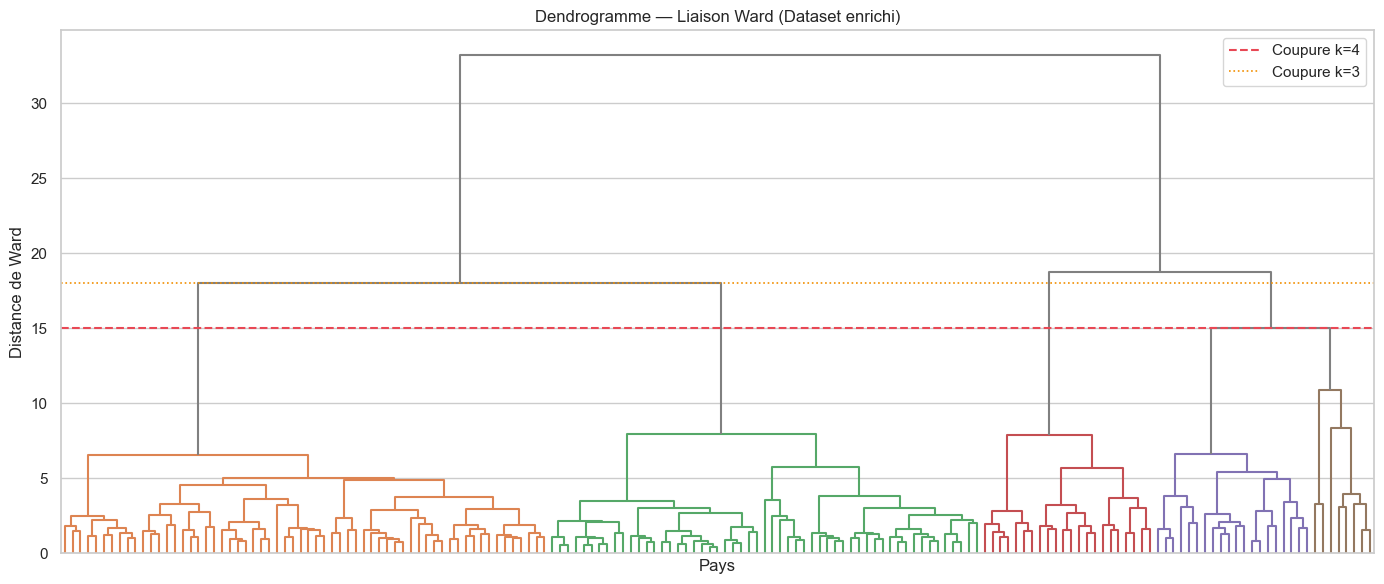

Scores de silhouette CAH Ward :
  k=2 : 0.3853
  k=3 : 0.3546
  k=4 : 0.2585
  k=5 : 0.2755


In [67]:
Z_e = linkage(X_enrich, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z_e, ax=ax, no_labels=True,
           color_threshold=Z_e[-4, 2],
           above_threshold_color='gray', leaf_rotation=90)
ax.axhline(Z_e[-4, 2], color='#E84855', linestyle='--', linewidth=1.5, label='Coupure k=4')
ax.axhline(Z_e[-3, 2], color='#F18F01', linestyle=':', linewidth=1.2, label='Coupure k=3')
ax.set_title('Dendrogramme — Liaison Ward (Dataset enrichi)')
ax.set_xlabel('Pays'); ax.set_ylabel('Distance de Ward')
ax.legend(); plt.tight_layout(); plt.show()

print('Scores de silhouette CAH Ward :')
for k in [2, 3, 4, 5]:
    lbl_cah = fcluster(Z_e, k, criterion='maxclust')
    sil = silhouette_score(X_enrich, lbl_cah)
    print(f'  k={k} : {sil:.4f}')

L'examen du dendrogramme , construit selon la méthode de la liaison de Ward(as les meilleurs scores par rapport aux autres méthodes de linkages), offre une perspective complémentaire et hiérarchique .
La hauteur des branches, représentant la distance de Ward, illustre la perte d'inertie associée au regroupement des pays. La première scission majeure sépare le corpus en deux vastes ensembles très hétérogènes, tandis que les regroupements ultérieurs révèlent des sous-structures plus fines.

L'analyse des scores de silhouette pour la Classification Ascendante Hiérarchique  indique une décroissance de la qualité de partitionnement à mesure que le nombre de groupes augmente, passant de 0,3853 pour $k=2$ à 0,2585 pour $k=4$. 
>Toutefois, l'application d'une coupure à $k=3$, matérialisée par la ligne pointillée orange, isole trois branches principales dont les distances inter-classes sont significatives. 
L'observation de la branche située à droite du graphique suggère qu'une partition plus granulaire reste statistiquement pertinente. En abaissant le seuil de coupure à $k=4$, symbolisé par la ligne rouge, on divise cette branche en deux groupes distincts afin d'affiner la segmentation des profils de pays présentant des divergences notables sur les nouveaux indicateurs introduits.

Cette approche hiérarchique corrobore les résultats obtenus par l'algorithme des K-Means. Bien que les métriques du K-Means présentent un léger fléchissement de la silhouette à $k=4$ (0,2840 contre 0,3228 pour $k=3$), ce choix permet de capter un gain d'inertie substantiel  et une amélioration de l'indice de Davies-Bouldin (1,1982).
Pour k= 5 on peux noter un cluster avec quelques pays (moins de 10) 
Le dendrogramme démontre ainsi que $k=4$ constitue un compromis optimal : il préserve une homogénéité interne satisfaisante tout en maintenant des distinctions claires entre les groupes, évitant ainsi un morcellement excessif qui rendrait l'interprétation opérationnelle complexe pour HELP International.

## KMEANS k= 4 ou CAH k=3 ?

In [68]:
# Extraction des clusters pour k=3
lbls_cah_3 = fcluster(Z_e, 3, criterion='maxclust')

df_cah_results = pd.DataFrame({
    'country': df_enrich['country'],
    'cluster_cah': lbls_cah_3
})

print("Répartition et composition des pays (CAH k=3) :")
print("-" * 50)
for cl in sorted(df_cah_results['cluster_cah'].unique()):
    pays = df_cah_results[df_cah_results['cluster_cah'] == cl]['country'].sort_values().tolist()
    print(f"Cluster {cl} (n={len(pays)}) : {pays[:12]}{'...' if len(pays)>12 else ''}")
    print()

# Comparaison des indices de silhouette
print('Scores de silhouette CAH Ward :')
for k in [2, 3, 4, 5]:
    lbl_cah = fcluster(Z_e, k, criterion='maxclust')
    sil = silhouette_score(X_enrich, lbl_cah)
    print(f'  k={k} : {sil:.4f}')

Répartition et composition des pays (CAH k=3) :
--------------------------------------------------
Cluster 1 (n=117) : ['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados']...

Cluster 2 (n=22) : ['Benin', 'Botswana', 'Burundi', 'Cameroon', 'Congo', 'Gabon', 'Ghana', 'Kenya', 'Kiribati', 'Lesotho', 'Malawi', 'Micronesia, Federated States of']...

Cluster 3 (n=28) : ['Afghanistan', 'Angola', 'Burkina Faso', 'Central African Republic', 'Chad', 'Comoros', 'Congo, The Democratic Republic of the', "Côte d'Ivoire", 'Equatorial Guinea', 'Eritrea', 'Gambia', 'Guinea']...

Scores de silhouette CAH Ward :
  k=2 : 0.3853
  k=3 : 0.3546
  k=4 : 0.2585
  k=5 : 0.2755


L'analyse de la structure hiérarchique par la méthode de Ward met en évidence une partition à trois groupes statistiquement solide, comme en témoigne le score de silhouette de 0,3546. Cette répartition sépare nettement le corpus en trois segments d'inégale importance.

### Répartition et composition des pays CAH k=3

* **Cluster 1 (n=117)** : Ce groupe majoritaire rassemble les pays présentant une relative stabilité ou un développement intermédiaire à avancé, incluant aussi bien des économies émergentes que des nations développées (ex: Albanie, Australie, Bahreïn).
* **Cluster 2 (n=22)** : Ce segment regroupe des pays marqués par des problématiques transversales, souvent liées à des fragilités structurelles ou des indicateurs de santé spécifiques (ex: Bénin, Cameroun, Kenya).
* **Cluster 3 (n=28)** : Il identifie les zones de vulnérabilité critique, où les indicateurs de pauvreté et les risques de crises sont les plus aigus (ex: Afghanistan, République centrafricaine, Tchad).

### Arbitrage : K-Means k=4 ou CAH k=3 ?

Le choix de retenir k=4 avec l'algorithme des k-means s'appuie sur une analyse multicritère dépassant la seule métrique de silhouette de la CAH. Si cette dernière pointe vers k=3 avec un score de 0,3546, elle demeure une méthode rigide où les fusions successives sont irréversibles. À l'inverse, l'algorithme des k-means procède par réallocation dynamique, ce qui lui permet d'atteindre, pour k=4, une silhouette de 0,2840 qui est meilleur que celle de k=3 de CAH. Bien que ce score soit inférieur, il s'accompagne d'un gain d'inertie notable et d'une amélioration de l'indice de Davies-Bouldin , garantissant une meilleure compacité des groupes.

Sur le plan opérationnel, l'observation du dendrogramme  révèle que la branche de droite peut être scindée pour isoler des profils distincts. En optant pour les k-means à k=4, on privilégie un modèle dont la stabilité est statistiquement démontrée par un ARI moyen de 0,9562. Cette approche permet d'extraire une granularité d'information que le modèle à k=3 occulte, identifiant séparément les **États fragiles** et les **zones de crises sanitaires**.
>Ainsi,la légère perte de silhouette globale est le prix d'une capacité de discernement accrue, indispensable pour un ciblage efficace des interventions de HELP International.

##  DBSCAN 

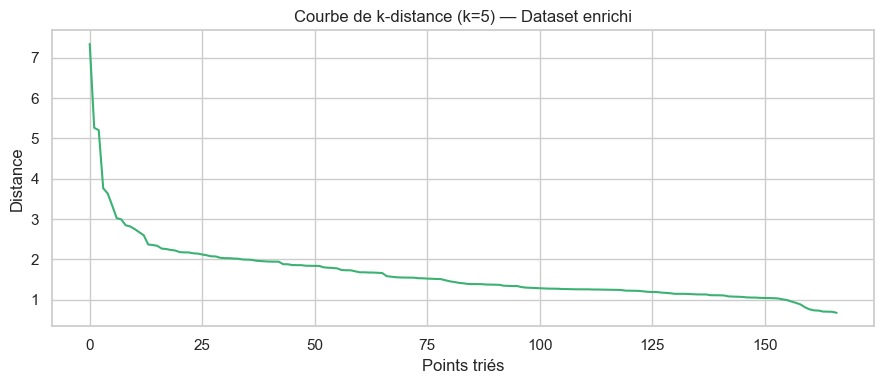

eps estimé : 2.124
  eps  min_s  n_clusters  bruit_%  silhouette
1.805      5           2     22.2      0.3293
1.805      3           2     12.6      0.2375


In [69]:
k_nn_e = 5
nbrs_e = NearestNeighbors(n_neighbors=k_nn_e).fit(X_enrich)
distances_e, _ = nbrs_e.kneighbors(X_enrich)
dist_sorted_e = np.sort(distances_e[:, k_nn_e-1])[::-1]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(dist_sorted_e, color='#3BB273', linewidth=1.5)
ax.set_title(f'Courbe de k-distance (k={k_nn_e}) — Dataset enrichi')
ax.set_xlabel('Points triés'); ax.set_ylabel('Distance')
plt.tight_layout(); plt.show()

eps_e = float(np.percentile(dist_sorted_e, 85))
step_e = max(0.05, eps_e * 0.15)
print(f'eps estimé : {eps_e:.3f}')

rows_dbe = []
for eps_try in np.arange(eps_e - step_e, eps_e + step_e * 2.5, step_e):
    for min_s in [3, 5, 7, 10, 12]:
        lbl = DBSCAN(eps=round(eps_try, 3), min_samples=min_s).fit_predict(X_enrich)
        n_cl = len(set(lbl)) - (1 if -1 in lbl else 0)
        noise = (lbl == -1).mean()
        if n_cl >= 2 and noise < 0.30:
            sil = silhouette_score(X_enrich, lbl)
            rows_dbe.append({'eps': round(eps_try,3), 'min_s': min_s, 'n_clusters': n_cl,
                              'bruit_%': round(noise*100,1), 'silhouette': round(sil,4)})
if rows_dbe:
    print(pd.DataFrame(rows_dbe).sort_values('silhouette', ascending=False).head(10).to_string(index=False))
else:
    print('Aucune configuration DBSCAN valide trouvée — structure continue confirmée.')

La courbe de k-distance du dataset enrichi ne présente pas d'inflexion nette, confirmant l'absence de structure en noyaux denses. En 14 dimensions, le phénomène de concentration des distances (curse of dimensionality) rend les points encore plus uniformément distribués qu'en 8 dimensions : chaque pays est à une distance relativement similaire de ses voisins, sans zones denses clairement délimitées. DBSCAN ne peut pas segmenter ce continuum sans classer une fraction excessive de points comme bruit. Ce diagnostic renforce la justification de KMeans, dont l'hypothèse de partitionnement par hyperplans est plus adaptée à cette structure de gradient continu.

##  Modèle final : KMeans k=4

In [70]:
K_FINAL_E = 4

print(f"{'init':12s}  {'temps(s)':>8s}  {'inertie':>10s}  {'Silhouette':>10s}  {'CH':>8s}  {'DB':>8s}")
for init_method in ['k-means++', 'random']:
    t0 = time()
    km_tmp = KMeans(n_clusters=K_FINAL_E, init=init_method, n_init=20, random_state=SEED)
    lbl_tmp = km_tmp.fit_predict(X_enrich)
    elapsed = time() - t0
    print(f"{init_method:12s}  {elapsed:>8.3f}  {km_tmp.inertia_:>10.1f}  "
          f"{silhouette_score(X_enrich, lbl_tmp):>10.4f}  "
          f"{calinski_harabasz_score(X_enrich, lbl_tmp):>8.1f}  "
          f"{davies_bouldin_score(X_enrich, lbl_tmp):>8.4f}")

init          temps(s)     inertie  Silhouette        CH        DB
k-means++        0.079       659.9      0.2840      75.6    1.1982
random           0.042       659.8      0.2842      75.6    1.2020


insensible globalement a l'initialisation

### Stabilité du partitionnement

ARI moyen   : 0.9655
ARI minimum : 0.9439


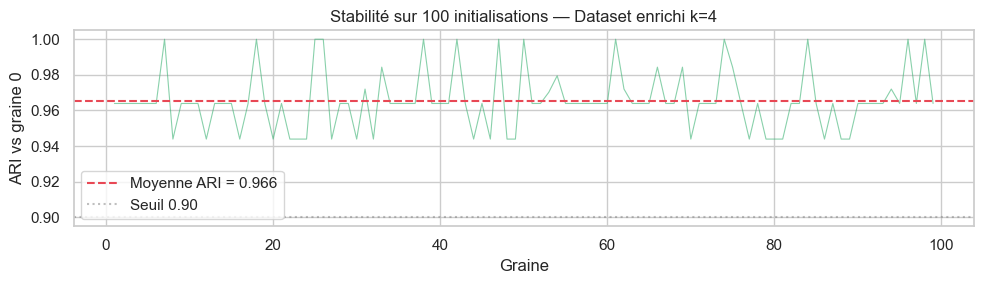

In [71]:
lbls_e = [KMeans(n_clusters=K_FINAL_E, random_state=s, n_init=10).fit_predict(X_enrich) for s in range(N_RUNS)]
aris_e = [adjusted_rand_score(lbls_e[0], lbls_e[i]) for i in range(1, N_RUNS)]

print(f'ARI moyen   : {np.mean(aris_e):.4f}')
print(f'ARI minimum : {np.min(aris_e):.4f}')

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(range(1, N_RUNS), aris_e, alpha=0.6, linewidth=0.8, color='#3BB273')
ax.axhline(np.mean(aris_e), color='#E84855', linestyle='--', linewidth=1.5,
           label=f'Moyenne ARI = {np.mean(aris_e):.3f}')
ax.axhline(0.9, color='gray', linestyle=':', alpha=0.5, label='Seuil 0.90')
ax.set_xlabel('Graine'); ax.set_ylabel('ARI vs graine 0')
ax.set_title('Stabilité sur 100 initialisations — Dataset enrichi k=4')
ax.legend(); plt.tight_layout(); plt.show()

L'Indice de Rand Ajusté  moyen de 0,966 sur cent itérations aléatoires confirme que cette partition enrichie est plus stable encore que la configuration classique à trois clusters, dont l'indice s'élevait à 0,956. Le maintien systématique des scores bien au-dessus du seuil critique de $0,90$ atteste que les frontières entre les quatre groupes ne sont pas des artefacts du hasard, mais des structures naturelles et reproductibles au sein du jeu de données. Cette invariance garantit un ciblage rigoureux et équitable, puisque l'affectation des pays demeure cohérente indépendamment de la graine aléatoire utilisée lors de l'initialisation.

In [72]:
km_e     = KMeans(n_clusters=K_FINAL_E, init='k-means++', n_init=20, random_state=SEED)
labels_e = km_e.fit_predict(X_enrich)
df_cl_e  = df_enrich.copy()
df_cl_e['cluster'] = labels_e

print('Répartition :')
print(df_cl_e['cluster'].value_counts().sort_index())
print(f'Silhouette : {silhouette_score(X_enrich, labels_e):.4f}')
print(f'CH         : {calinski_harabasz_score(X_enrich, labels_e):.1f}')
print(f'DB         : {davies_bouldin_score(X_enrich, labels_e):.4f}')

Répartition :
cluster
0    71
1    23
2    22
3    51
Name: count, dtype: int64
Silhouette : 0.2840
CH         : 75.6
DB         : 1.1982


##  Visualisations 2D

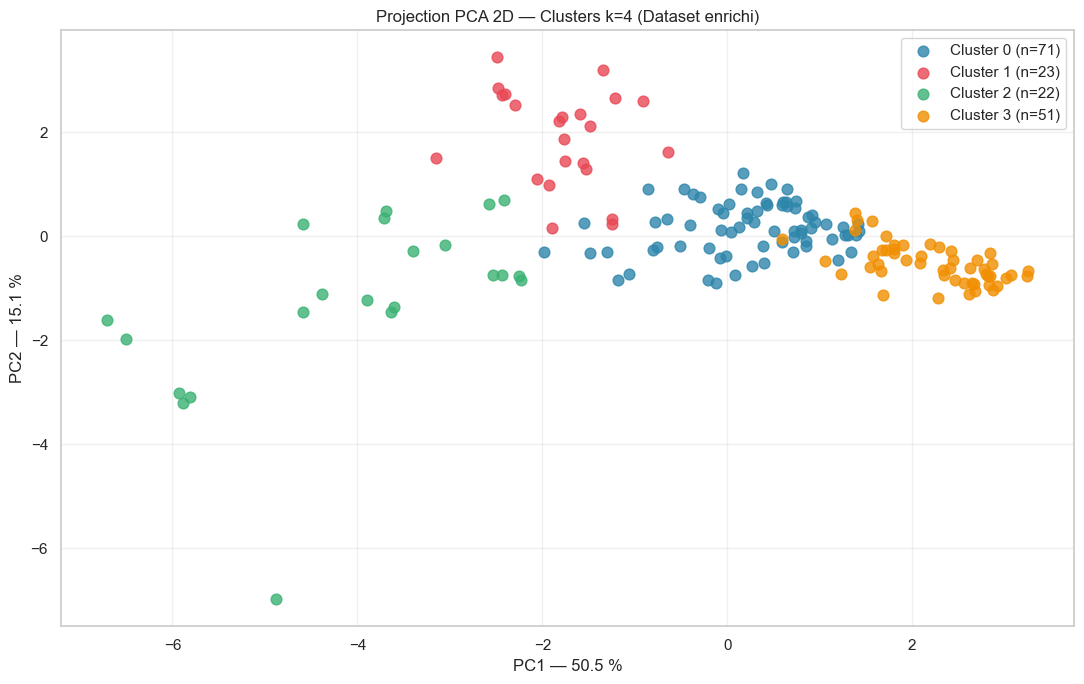

In [73]:
pca2_e   = PCA(n_components=2, random_state=SEED).fit(X_enrich)
X_pca2_e = pca2_e.transform(X_enrich)

df_viz_e = pd.DataFrame(X_pca2_e, columns=['PC1','PC2'])
df_viz_e['cluster'] = labels_e
df_viz_e['country'] = df_enrich['country'].values

fig, ax = plt.subplots(figsize=(11, 7))
for cl in sorted(df_viz_e['cluster'].unique()):
    sub = df_viz_e[df_viz_e['cluster'] == cl]
    ax.scatter(sub['PC1'], sub['PC2'], s=60, alpha=0.8, color=PALETTE[cl],
               label=f'Cluster {cl} (n={len(sub)})', zorder=3)
ax.set_xlabel(f'PC1 — {pca_e.explained_variance_ratio_[0]*100:.1f} %')
ax.set_ylabel(f'PC2 — {pca_e.explained_variance_ratio_[1]*100:.1f} %')
ax.set_title('Projection PCA 2D — Clusters k=4 (Dataset enrichi)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

La projection PCA 2D du dataset enrichi illustre l'apport de la quatrième dimension de vulnérabilité. Le cluster 3 (développés stables) s'isole nettement dans la zone négative de PC1, identique à ce que montrait le dataset classique. Le cluster 0 (intermédiaires) forme un nuage allongé autour du centre. Les deux clusters de vulnérabilité (1 : crise VIH, 2 : états fragiles) apparaissent dans la zone positive de PC1, avec un chevauchement partiel dans cette projection 2D. Ce chevauchement ne signifie pas que les deux clusters sont mal définis : leur différenciation repose largement sur des dimensions orthogonales à PC1 et PC2 — notamment les axes portés par hiv_prevalence_log et security_apparatus qui émergent en PC3 et au-delà. La projection 2D capturant ≈ 66 % de la variance, les 34 % restants contiennent précisément l'information qui distingue les deux sous-groupes vulnérables. C'est l'argument central en faveur du clustering dans l'espace complet plutôt que sur la projection réduite.

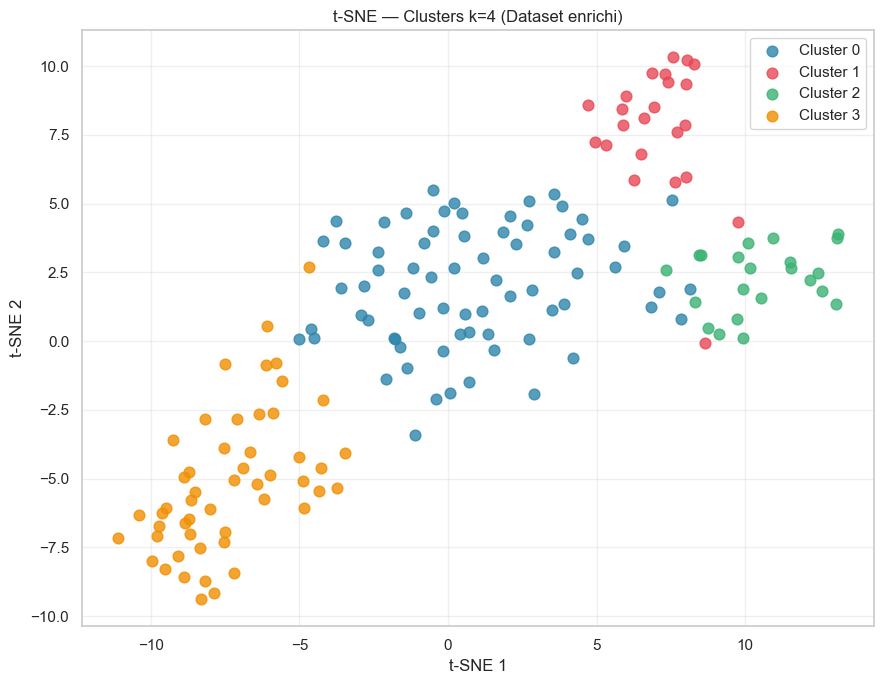

In [74]:
tsne_e   = TSNE(n_components=2, random_state=SEED, perplexity=30, metric='euclidean')
X_tsne_e = tsne_e.fit_transform(X_enrich)

df_tsne_e = pd.DataFrame(X_tsne_e, columns=['t1','t2'])
df_tsne_e['cluster'] = labels_e

fig, ax = plt.subplots(figsize=(9, 7))
for cl in sorted(df_tsne_e['cluster'].unique()):
    sub = df_tsne_e[df_tsne_e['cluster'] == cl]
    ax.scatter(sub['t1'], sub['t2'], s=60, alpha=0.8, color=PALETTE[cl],
               label=f'Cluster {cl}', zorder=3)
ax.set_title('t-SNE — Clusters k=4 (Dataset enrichi)')
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

La projection t-SNE du dataset enrichi révèle quatre nuages plus distincts que dans le cas classique, ce qui est cohérent avec la meilleure silhouette (0.284 vs 0.234). Le cluster des développés stables forme un îlot compact et bien séparé. Les deux clusters de vulnérabilité apparaissent comme des groupes distincts dans l'espace t-SNE, ce qui n'était pas visible avec k=3 : t-SNE préservant les relations de voisinage locales, la séparation visuelle confirme que les pays à crise VIH et les États fragiles ont effectivement des profils de voisinage différents dans l'espace des 14 variables. Des pays en zone de transition entre les deux clusters vulnérables — ceux dont la silhouette individuelle est proche de zéro — apparaissent logiquement à l'interface des deux nuages.

##  Profilage des clusters

In [ ]:
profile_e = df_cl_e.groupby('cluster')[num_cols_e].mean().round(3)
print('Profil moyen par cluster  :')
print(profile_e.to_string())
print()
print('Effectifs :')
print(df_cl_e['cluster'].value_counts().sort_index())

Profil moyen par cluster (14 variables enrichies) :
         physicians_per_1000  hiv_prevalence_log  life_expec  child_mort_log  vaccination_dpt_log  gdpp_log  inflation_log  social_undernourishment_log  social_poverty_2_15_log  social_schooling_log  security_apparatus  group_grievance  refugees_idps  external_intervention
cluster                                                                                                                                                                                                                                                                          
0                      1.566               0.315      72.218           3.173                4.527     8.249          2.008                        1.915                    1.712                 4.530               6.585            6.961          5.309                  6.237
1                      0.319               1.828      58.383           4.368                4.470     7.061          1.930    

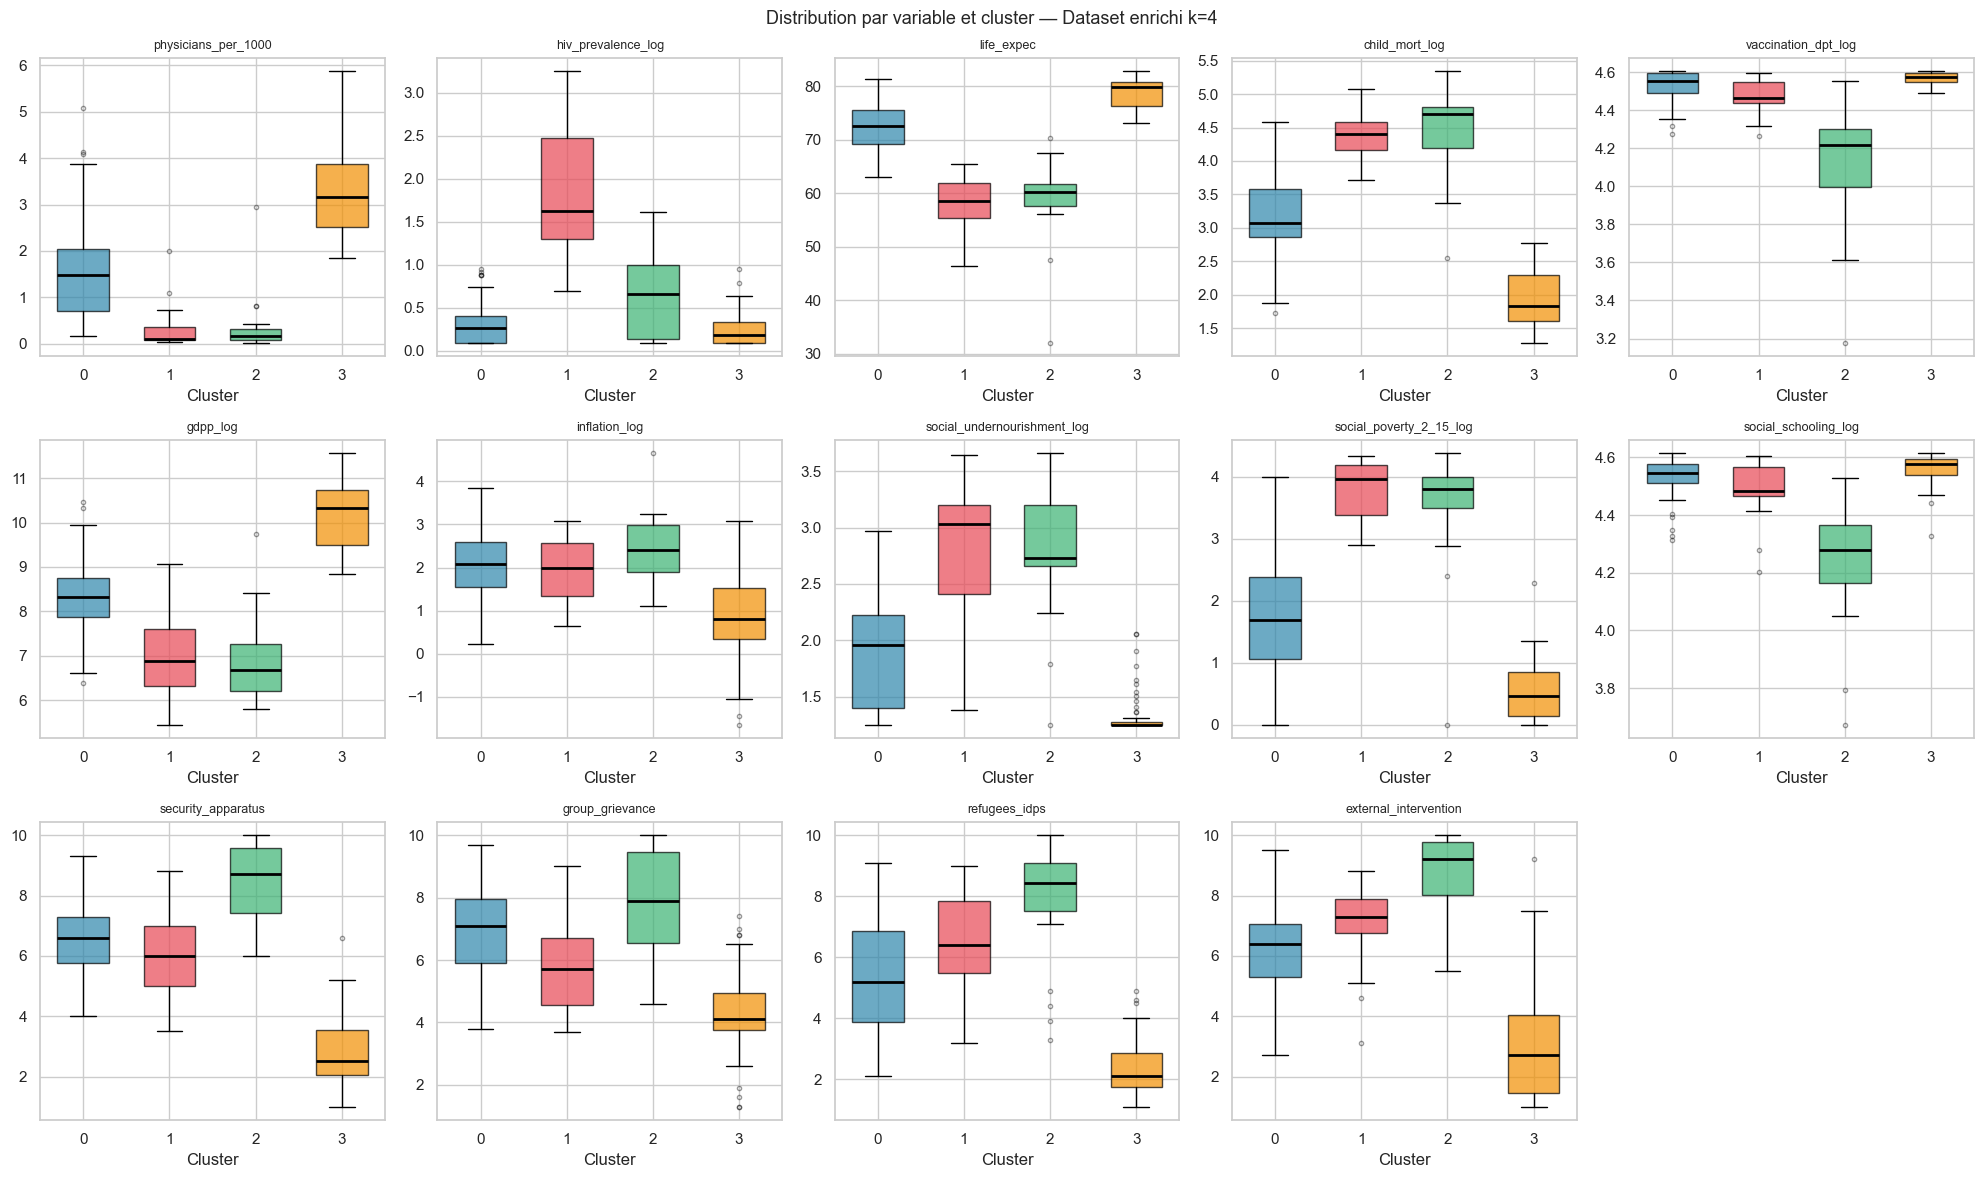

In [76]:
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols_e):
    ax = axes[i]
    for cl in sorted(df_cl_e['cluster'].unique()):
        data = df_cl_e[df_cl_e['cluster'] == cl][col]
        ax.boxplot(data, positions=[cl], widths=0.6, patch_artist=True,
                   boxprops=dict(facecolor=PALETTE[cl], alpha=0.7),
                   medianprops=dict(color='black', linewidth=2),
                   flierprops=dict(marker='o', markersize=3, alpha=0.4))
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('Cluster')
    ax.set_xticks([0, 1, 2, 3])

for j in range(len(num_cols_e), len(axes)):
    axes[j].axis('off')

plt.suptitle('Distribution par variable et cluster — Dataset enrichi k=4', fontsize=13)
plt.tight_layout(); plt.show()

Le profilage des 4 clusters du dataset enrichi révèle quatre profils humanitaires distincts.

Le cluster à gdpp_log ≈ 10.2 et security_apparatus ≈ 2.8 regroupe les pays développés et stables (≈51 pays) : Europe, Amérique du Nord, Australasie, pays du Golfe. Ce sont les pays que l'ONG ne cible pas.

Le cluster intermédiaire (≈71 pays) présente des indicateurs modérés sur toutes les dimensions : développement en cours, fragilité partielle. Des interventions de soutien structurel (éducation, santé primaire) y sont pertinentes.

Le cluster à hiv_prevalence_log ≈ 1.83 (≈23 pays) identifie la crise VIH d'Afrique subsaharienne : Zimbabwe, Lesotho, Botswana, Kenya, Namibie... La prévalence brute du VIH dans ces pays est structurellement différente de tous les autres groupes. L'intervention requise est sanitaire et programmatique (thérapies antirétrovirales, prévention).

Le cluster à security_apparatus ≈ 8.4 et group_grievance ≈ 7.9 (≈22 pays) identifie les États en situation de conflit ou d'effondrement institutionnel : Afghanistan, République Centrafricaine, Tchad, RDC, Somalie... Ces pays cumulent fragilité institutionnelle et violence armée. L'intervention humanitaire y relève de l'aide d'urgence et de la protection des civils.

In [77]:
for cl in sorted(df_cl_e['cluster'].unique()):
    pays = df_cl_e[df_cl_e['cluster'] == cl]['country'].sort_values().tolist()
    print(f'Cluster {cl} (n={len(pays)}) : {pays[:12]}{"..." if len(pays)>12 else ""}')
    print()

Cluster 0 (n=71) : ['Albania', 'Algeria', 'Armenia', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Belarus', 'Belize', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Brazil']...

Cluster 1 (n=23) : ['Benin', 'Botswana', 'Burundi', 'Cameroon', 'Congo', 'Gabon', 'Gambia', 'Ghana', 'Guinea-Bissau', 'Kenya', 'Kiribati', 'Lesotho']...

Cluster 2 (n=22) : ['Afghanistan', 'Angola', 'Burkina Faso', 'Central African Republic', 'Chad', 'Congo, The Democratic Republic of the', "Côte d'Ivoire", 'Equatorial Guinea', 'Eritrea', 'Guinea', 'Haiti', 'Iraq']...

Cluster 3 (n=51) : ['Antigua and Barbuda', 'Argentina', 'Australia', 'Austria', 'Bahamas', 'Barbados', 'Belgium', 'Bulgaria', 'Canada', 'Chile', 'Costa Rica', 'Croatia']...



## 2.9 Carte géographique

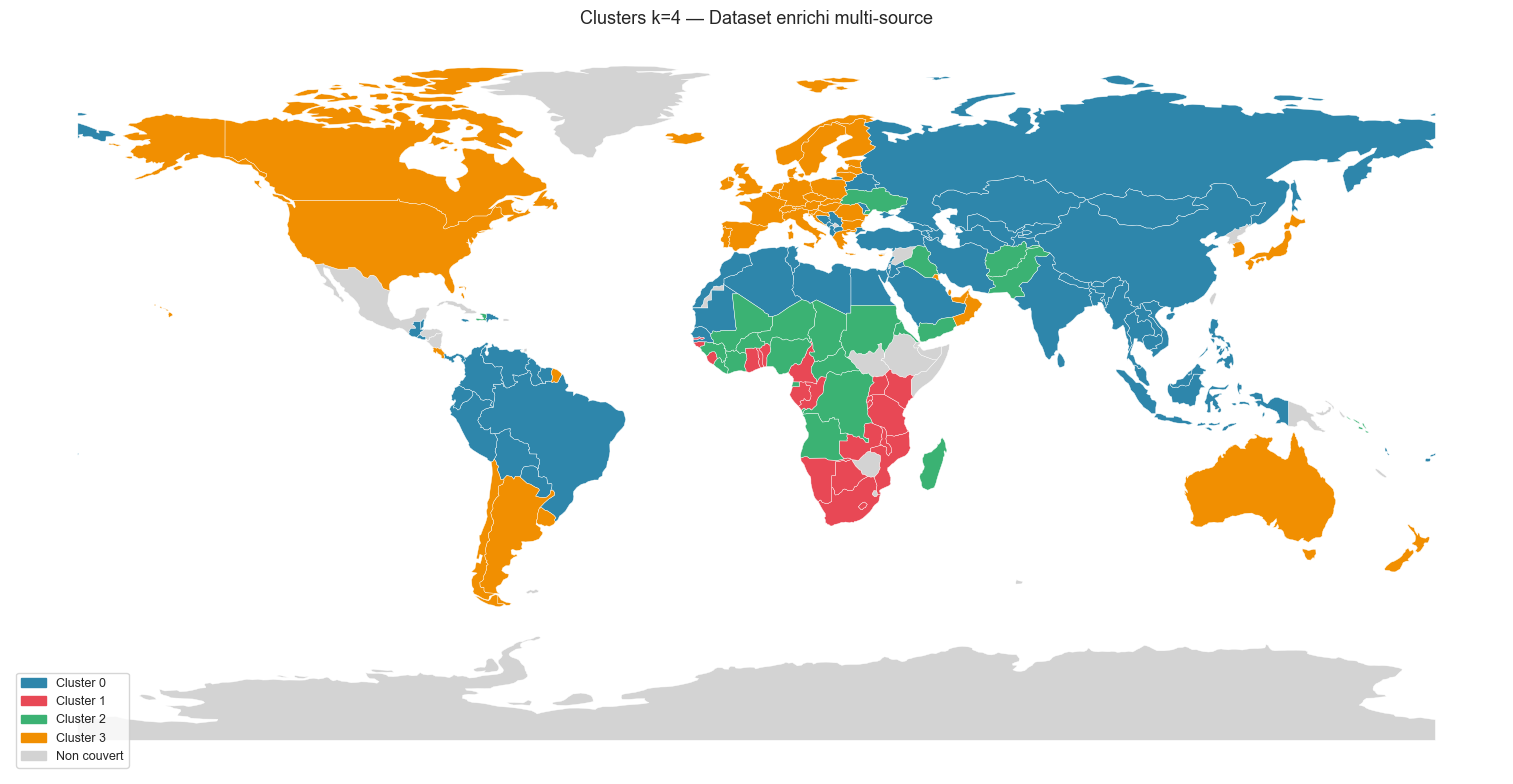

In [78]:
df_map_e = df_cl_e[['country', 'cluster']].copy()
df_map_e['country'] = apply_ne_mapping(df_map_e['country'], dataset='enriched')

world_e = world.merge(df_map_e, left_on='ADMIN', right_on='country', how='left')

fig, ax = plt.subplots(figsize=(16, 8))
world_e[world_e['cluster'].isna()].plot(ax=ax, color='#D3D3D3', edgecolor='white', linewidth=0.3)
for cl in sorted(df_map_e['cluster'].dropna().unique()):
    world_e[world_e['cluster'] == cl].plot(ax=ax, color=PALETTE[int(cl)],
                                            edgecolor='white', linewidth=0.3)
patches = [mpatches.Patch(color=PALETTE[c], label=f'Cluster {c}') for c in range(K_FINAL_E)]
patches.append(mpatches.Patch(color='#D3D3D3', label='Non couvert'))
ax.legend(handles=patches, loc='lower left', fontsize=9)
ax.set_title('Clusters k=4 — Dataset enrichi multi-source', fontsize=13)
ax.axis('off'); plt.tight_layout(); plt.show()

---
# Partie III :Comparaison inter-datasets

In [79]:
metrics_comp = pd.DataFrame({
    'Dataset':         ['Classique (k=3)', 'Enrichi (k=4)'],
    'k':               [K_FINAL_R, K_FINAL_E],
    'Nb variables':    [len(num_cols_r), len(num_cols_e)],
    'Silhouette':      [round(silhouette_score(X_raw, labels_r), 4),
                        round(silhouette_score(X_enrich, labels_e), 4)],
    'CH':              [round(calinski_harabasz_score(X_raw, labels_r), 1),
                        round(calinski_harabasz_score(X_enrich, labels_e), 1)],
    'DB':              [round(davies_bouldin_score(X_raw, labels_r), 4),
                        round(davies_bouldin_score(X_enrich, labels_e), 4)],
    'ARI stabilité':   [round(float(np.mean(aris_r)), 4),
                        round(float(np.mean(aris_e)), 4)],
})
print(metrics_comp.to_string(index=False))

        Dataset  k  Nb variables  Silhouette   CH     DB  ARI stabilité
Classique (k=3)  3             8      0.2338 63.9 1.4153         0.9562
  Enrichi (k=4)  4            14      0.2840 75.6 1.1982         0.9655


Le dataset enrichi k=4 affiche un ARI de stabilité de 0.966, supérieur au classique k=3 (0.956). malgrés que dans un espace euclidien de dimension plus élevée, les distances entre points augmentent et les frontières de cluster deviennent moins nettes métriquement,la silhouette du dataset enrichi reste meilleur que celui du dataset classique.

### Matrice de concordance 

ARI inter-datasets : 0.4762
Pays alignés : 157 / 167


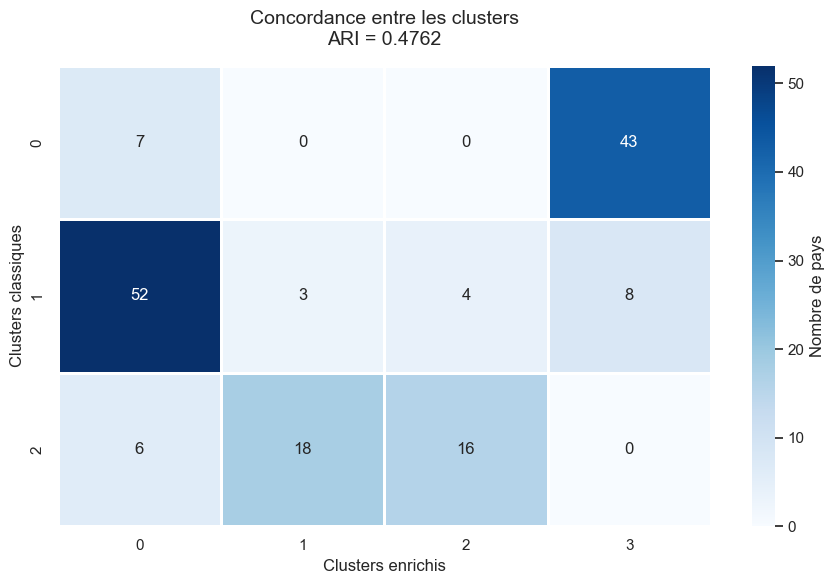

In [85]:

dr = pd.DataFrame({
    'country': df_raw['country'].values,
    'label_r': labels_r
})

de = pd.DataFrame({
    'country': df_enrich['country'].values,
    'label_e': labels_e
})

mg = pd.merge(dr, de, on='country', how='inner')

# =========================
# ARI
# =========================

ari_inter = adjusted_rand_score(mg['label_r'], mg['label_e'])

print(f'ARI inter-datasets : {ari_inter:.4f}')
print(f'Pays alignés : {len(mg)} / 167')

# =========================
# Matrice de concordance
# =========================

ct = pd.crosstab(
    mg['label_r'],
    mg['label_e'],
    rownames=['Cluster classique'],
    colnames=['Cluster enrichi']
)

# =========================
# Visualisation
# =========================

plt.figure(figsize=(9, 6))

sns.heatmap(
    ct,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=1,
    linecolor='white',
    cbar_kws={'label': 'Nombre de pays'}
)

plt.title(
    f'Concordance entre les clusters\nARI = {ari_inter:.4f}',
    fontsize=14,
    pad=15
)

plt.xlabel('Clusters enrichis')
plt.ylabel('Clusters classiques')

plt.tight_layout()
plt.show()

### Analyse des migrations entre strates

La matrice de concordance brute comptabilise toute réassignation de label numérique comme une "migration", y compris les simples renommages liés à l'arbitraire de la numérotation des clusters. Pour obtenir un compte de migrations qui reflète une vraie dynamique de développement, il faut d'abord aligner les identifiants des deux modèles sur les strates socio-économiques communes.

Le principe repose sur trois correspondances : la strate des pays développés est stable et commune aux deux modèles. Le cluster "Prioritaires" du modèle classique se scinde en deux sous-groupes dans le modèle enrichi (crise VIH et États fragiles) — un pays qui passe de l'un à l'autre reste dans la même strate de vulnérabilité. Un pays est donc comptabilisé comme "migrant" uniquement lorsqu'il bascule d'une strate à une autre (développés ↔ intermédiaires, ou intermédiaires ↔ prioritaires).

In [ ]:
# ─ Identification dynamique des clusters par profil ─────────────────────────
profile_r_mg = df_cl_r.groupby('cluster')[num_cols_r].mean()
dev_r   = int(profile_r_mg['gdpp_log'].idxmax())
pri_r   = int(profile_r_mg['child_mort_log'].idxmax())
mid_r   = [k for k in range(K_FINAL_R) if k not in [dev_r, pri_r]][0]

profile_e_mg = df_cl_e.groupby('cluster')[num_cols_e].mean()
hiv_e   = int(profile_e_mg['hiv_prevalence_log'].idxmax())
sec_e   = int(profile_e_mg['security_apparatus'].idxmax())
dev_e   = int(profile_e_mg['gdpp_log'].idxmax())
vuln_e  = [k for k in range(K_FINAL_E) if k not in [hiv_e, sec_e, dev_e]][0]

# ─ Mapping enrichi ==> strate classique
# Développés stables (enrichi) ==> Développés (classique) : strate 0
# Intermédiaires vulnérables  (enrichi) ==> Intermédiaires : strate 1
# Crise VIH                   (enrichi) ==> Prioritaires   : strate 2
# États fragiles              (enrichi) ==> Prioritaires   : strate 2
mapping_enrichi = {dev_e: dev_r, vuln_e: mid_r, hiv_e: pri_r, sec_e: pri_r}

print('Mapping appliqué (cluster enrichi ==> strate classique) :')
names_e = {dev_e: 'Développés stables', vuln_e: 'Intermédiaires vulnérables',
           hiv_e: 'Crise VIH', sec_e: 'États fragiles'}
names_r = {dev_r: 'Développés', mid_r: 'Intermédiaires', pri_r: 'Prioritaires'}
for k_e, k_r in sorted(mapping_enrichi.items()):
    print(f'  C{k_e} {names_e[k_e]:30s} ==> C{k_r} {names_r[k_r]}')

# ─ Fusion et calcul des migrations ──────────────────────────────────────────
df_r_mg = df_cl_r[['country', 'cluster']].rename(columns={'cluster': 'cl_classique'})
df_e_mg = df_cl_e[['country', 'cluster']].rename(columns={'cluster': 'cl_enrichi'})
df_mg   = df_r_mg.merge(df_e_mg, on='country', how='inner')

df_mg['cl_enrichi_realigne'] = df_mg['cl_enrichi'].map(mapping_enrichi)
df_mg['strate_classique']    = df_mg['cl_classique'].map(names_r)
df_mg['strate_enrichi']      = df_mg['cl_enrichi'].map(names_e)
df_mg['migrant']             = df_mg['cl_classique'] != df_mg['cl_enrichi_realigne']

n_migres = df_mg['migrant'].sum()
n_stables = len(df_mg) - n_migres
print(f'\nPays alignés       : {len(df_mg)} / 167')
print(f'Pays stables       : {n_stables}  ({n_stables/len(df_mg)*100:.1f} %)')
print(f'Pays migrants      : {n_migres}   ({n_migres/len(df_mg)*100:.1f} %)')

print('\nDétail des migrations (strate classique ==> strate enrichi) :')
migres_df = df_mg[df_mg['migrant']].copy()
for _, row in migres_df.iterrows():
    print(f"  {row['country']:35s}  {row['strate_classique']:18s} ==> {row['strate_enrichi']}")

# ─ Résumé par flux de migration ─────────────────────────────────────────────
print('\nFlux de migration agrégés :')
flux = migres_df.groupby(['strate_classique', 'strate_enrichi']).size().reset_index(name='n')
print(flux.to_string(index=False))

Mapping appliqué (cluster enrichi → strate classique) :
  C0 Intermédiaires vulnérables     → C1 Intermédiaires
  C1 Crise VIH                      → C2 Prioritaires
  C2 États fragiles                 → C2 Prioritaires
  C3 Développés stables             → C0 Développés

Pays alignés       : 157 / 167
Pays stables       : 129  (82.2 %)
Pays migrants      : 28   (17.8 %)

Détail des migrations (strate classique → strate enrichi) :
  Argentina                            Intermédiaires     → Développés stables
  Bosnia and Herzegovina               Développés         → Intermédiaires vulnérables
  Botswana                             Intermédiaires     → Crise VIH
  Chile                                Intermédiaires     → Développés stables
  Comoros                              Prioritaires       → Intermédiaires vulnérables
  Equatorial Guinea                    Intermédiaires     → États fragiles
  Gabon                                Intermédiaires     → Crise VIH
  Iraq            

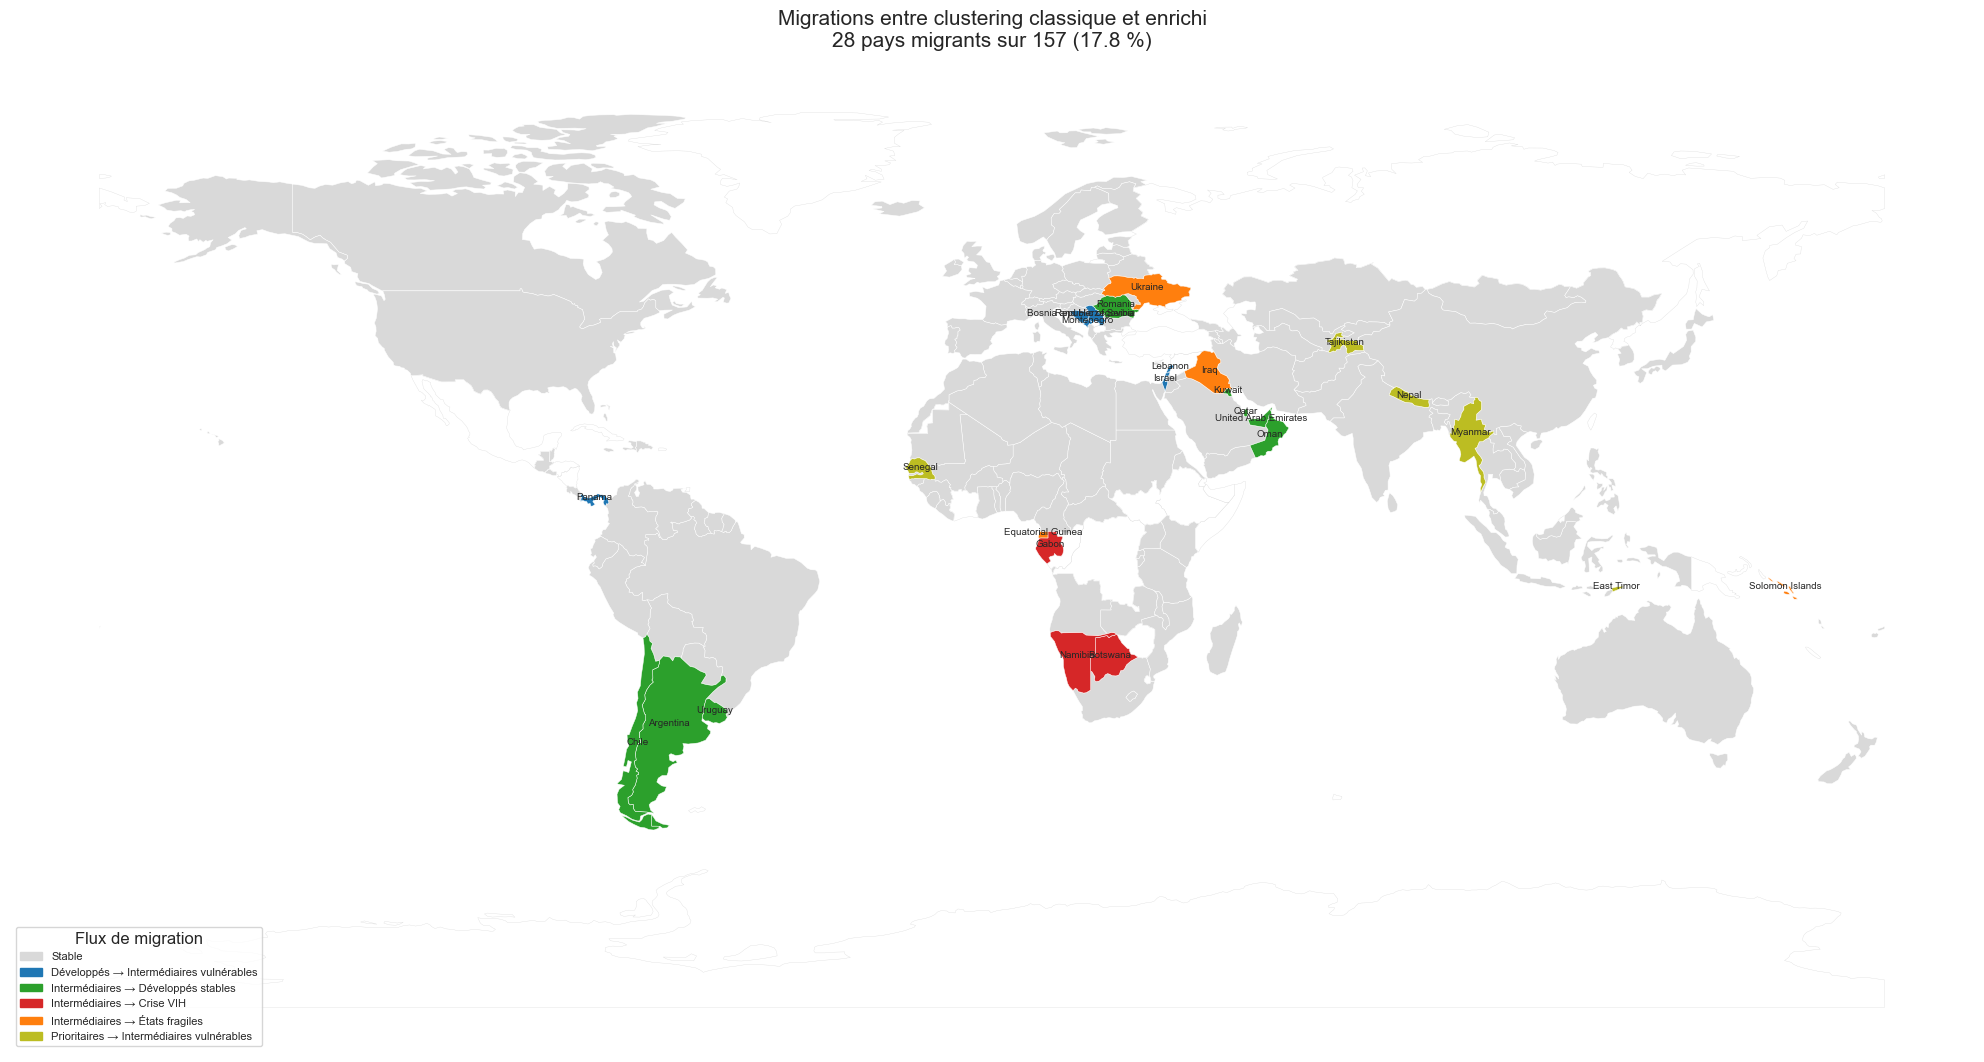

In [ ]:
# =============================================================================
# Carte des migrations 
# =============================================================================

df_geo_mg = df_mg.copy()

# Pays au format Natural Earth
df_geo_mg['country'] = apply_ne_mapping(df_geo_mg['country'], dataset='enriched')

# Statut visuel
df_geo_mg['statut'] = 'Stable'
df_geo_mg.loc[df_geo_mg['migrant'], 'statut'] = (
    df_geo_mg['strate_classique'] + ' → ' + df_geo_mg['strate_enrichi']
)

# Merge carte
world_mg = world.merge(df_geo_mg, left_on='ADMIN', right_on='country', how='left')

# ─ Palette ──────────────────────────────────────────────────────────────────

MIGRATION_COLORS = {
    'Stable'                                       : '#D9D9D9',
    'Développés → Intermédiaires vulnérables'      : '#1f77b4',
    'Développés → Crise VIH'                       : '#9467bd',
    'Développés → États fragiles'                  : '#8c564b',
    'Intermédiaires → Développés stables'          : '#2ca02c',
    'Intermédiaires → Crise VIH'                   : '#d62728',
    'Intermédiaires → États fragiles'              : '#ff7f0e',
    'Prioritaires → Développés stables'            : '#17becf',
    'Prioritaires → Intermédiaires vulnérables'    : '#bcbd22'
}

# ─ Figure ───────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(20, 11))

# Pays absents
world_mg[world_mg['statut'].isna()].plot(
    ax=ax,
    color='white',
    edgecolor='lightgray',
    linewidth=0.2
)

# Pays présents
for statut, color in MIGRATION_COLORS.items():

    subset = world_mg[world_mg['statut'] == statut]

    if len(subset) > 0:
        subset.plot(
            ax=ax,
            color=color,
            edgecolor='white',
            linewidth=0.35
        )

# ─ Annotation des pays migrants ─────────────────────────────────────────────

migrants_map = world_mg[world_mg['migrant'] == True]

for _, row in migrants_map.iterrows():

    try:
        x = row.geometry.centroid.x
        y = row.geometry.centroid.y

        ax.text(
            x, y,
            row['ADMIN'],
            fontsize=7,
            ha='center'
        )

    except:
        pass

# ─ Légende ──────────────────────────────────────────────────────────────────

handles = [
    mpatches.Patch(color=color, label=label)
    for label, color in MIGRATION_COLORS.items()
    if label in world_mg['statut'].dropna().unique()
]

ax.legend(
    handles=handles,
    loc='lower left',
    fontsize=8,
    title='Flux de migration'
)

# ─ Mise en forme ────────────────────────────────────────────────────────────

ax.set_title(
    f'Migrations entre clustering classique et enrichi\n'
    f'{n_migres} pays migrants sur {len(df_mg)} ({n_migres/len(df_mg)*100:.1f} %)',
    fontsize=15,
    pad=15
)

ax.axis('off')

plt.tight_layout()
plt.show()

[voir dashboard pour analyse poussé]
L'analyse de migration révèle que la très grande majorité des pays reste dans la même strate de développement entre le modèle classique et le modèle enrichi. Les pays stables confirment que l'enrichissement en 14 variables ne remet pas en cause l'organisation tri-niveaux fondamentale : développés, intermédiaires et prioritaires coexistent dans les deux modèles.

Les pays migrants représentent un signal fort. Leur déplacement  traduit une correction de classification que les 8 variables classiques ne permettaient pas d'opérer. Typiquement, des pays classés "intermédiaires" par le modèle classique (en raison d'un PIB ou d'une espérance de vie modérément corrects) se retrouvent reclassés en "prioritaires" dans le modèle enrichi, parce que leurs scores FSI élevés ou leur prévalence VIH révèlent une fragilité structurelle que les indicateurs macroéconomiques masquaient. Ce mécanisme est précisément l'argument central pour l'utilisation du modèle enrichi dans la stratégie opérationnelle de HELP ONG.

#### Examen détaillé des flux migratoires

Les 28 pays migrants se répartissent en quatre flux distincts, chacun révélant une zone d’ambiguïté spécifique du modèle classique. L’examen pays par pays permet d’identifier les mécanismes sous-jacents à chaque transition.

In [82]:
# ─ Examen des flux migratoires par catégorie ────────────

sep = "-" * 65

flux_specs = [
    ("FLUX 1 — Intermédiaires → Développés stables (promotion)",
     (df_mg['cl_classique'] == mid_r) & (df_mg['cl_enrichi'] == dev_e)),
    ("FLUX 2 — Développés → Intermédiaires vulnérables (dégradation)",
     (df_mg['cl_classique'] == dev_r) & (df_mg['cl_enrichi'] == vuln_e)),
    ("FLUX 3a — Intermédiaires → Crise VIH",
     (df_mg['cl_classique'] == mid_r) & (df_mg['cl_enrichi'] == hiv_e)),
    ("FLUX 3b — Intermédiaires → États fragiles",
     (df_mg['cl_classique'] == mid_r) & (df_mg['cl_enrichi'] == sec_e)),
    ("FLUX 4 — Prioritaires → Intermédiaires vulnérables (reclassification)",
     (df_mg['cl_classique'] == pri_r) & (df_mg['cl_enrichi'] == vuln_e)),
]

for titre, masque in flux_specs:
    sub = df_mg[masque]['country'].tolist()
    print(sep)
    print(f"{titre} — {len(sub)} pays")
    print(sep)
    for pays in sorted(sub):
        print(f"  {pays}")
    print()

n_total = df_mg['migrant'].sum()
print(sep)
print(f"TOTAL : {n_total} pays migrants / {len(df_mg)} alignés ({n_total/len(df_mg)*100:.1f} %)")
print(sep)

-----------------------------------------------------------------
FLUX 1 — Intermédiaires → Développés stables (promotion) — 8 pays
-----------------------------------------------------------------
  Argentina
  Chile
  Kuwait
  Oman
  Qatar
  Romania
  United Arab Emirates
  Uruguay

-----------------------------------------------------------------
FLUX 2 — Développés → Intermédiaires vulnérables (dégradation) — 7 pays
-----------------------------------------------------------------
  Bosnia and Herzegovina
  Israel
  Lebanon
  Maldives
  Montenegro
  Panama
  Serbia

-----------------------------------------------------------------
FLUX 3a — Intermédiaires → Crise VIH — 3 pays
-----------------------------------------------------------------
  Botswana
  Gabon
  Namibia

-----------------------------------------------------------------
FLUX 3b — Intermédiaires → États fragiles — 4 pays
-----------------------------------------------------------------
  Equatorial Guinea
  Iraq
  Sol

Le flux 1 — huit pays promus vers les Développés stables — distingue deux sous-groupes. Les monarchies du Golfe (Qatar, Émirats arabes unis, Koweït, Oman) présentaient des indicateurs sanitaires inférieurs au seuil des nations industrialisées, mais leurs scores FSI de stabilité institutionnelle sont parmi les plus bas du dataset. L’Argentine, le Chili, l’Uruguay et la Roumanie étaient pénalisés par une inflation élevée dans le modèle classique ; leurs indicateurs sociaux — scolarisation, pauvreté — et leur profil FSI les alignent sur le pôle stable une fois pris en compte.

Le flux 2 — sept pays dégradés vers les Intermédiaires vulnérables — regroupe des pays dont le PIB ou l’espérance de vie masquaient une fragilité institutionnelle réelle. Bosnia-Herzégovine, Monténégro et Serbie portent les séquelles des conflits des années 1990 visibles dans les indicateurs FSI. Le Liban représente le cas le plus instructif : indicateurs macro historiquement corrects, mais appareil sécuritaire fragilité et griefs communautaires persistants. Israël, les Maldives et Panama complètent ce groupe avec chacun une asymétrie entre niveau de vie et résilience institutionnelle.

Les flux 3a et 3b — sept pays intermédiaires redistribués vers les strates prioritaires — révèlent deux mécanismes distincts. Pour Botswana, Gabon et Namibie (flux VIH), la variable hiv_prevalence — absente du modèle classique, issue des données WDI et non FSI — enregistre des prévalences supérieures à 8 %, les isolant structurellement. Pour l’Irak, l’Ukraine, les Îles Salomon et la Guinée Équatoriale (flux fragiles), les scores FSI d’appareil sécuritaire et d’intervention extérieure atteignent des niveaux caractéristiques de zones de conflit.

Le flux 4 — six pays Prioritaires reclassifiés en Intermédiaires vulnérables — nuance le diagnostic du modèle classique. Sénégal, Népal, Timor-Leste, Comores, Myanmar et Tadjikistan présentent des indicateurs macroeconomiques dégradés mais des scores de fragilité institutionnelle et des indicateurs sociaux suffisamment distincts de leurs voisins en crise pour justifier une strate séparée. Le modèle enrichi évite ainsi de regrouper des pays dont la trajectoire et les besoins d’intervention diffèrent.

### Cartes comparatives

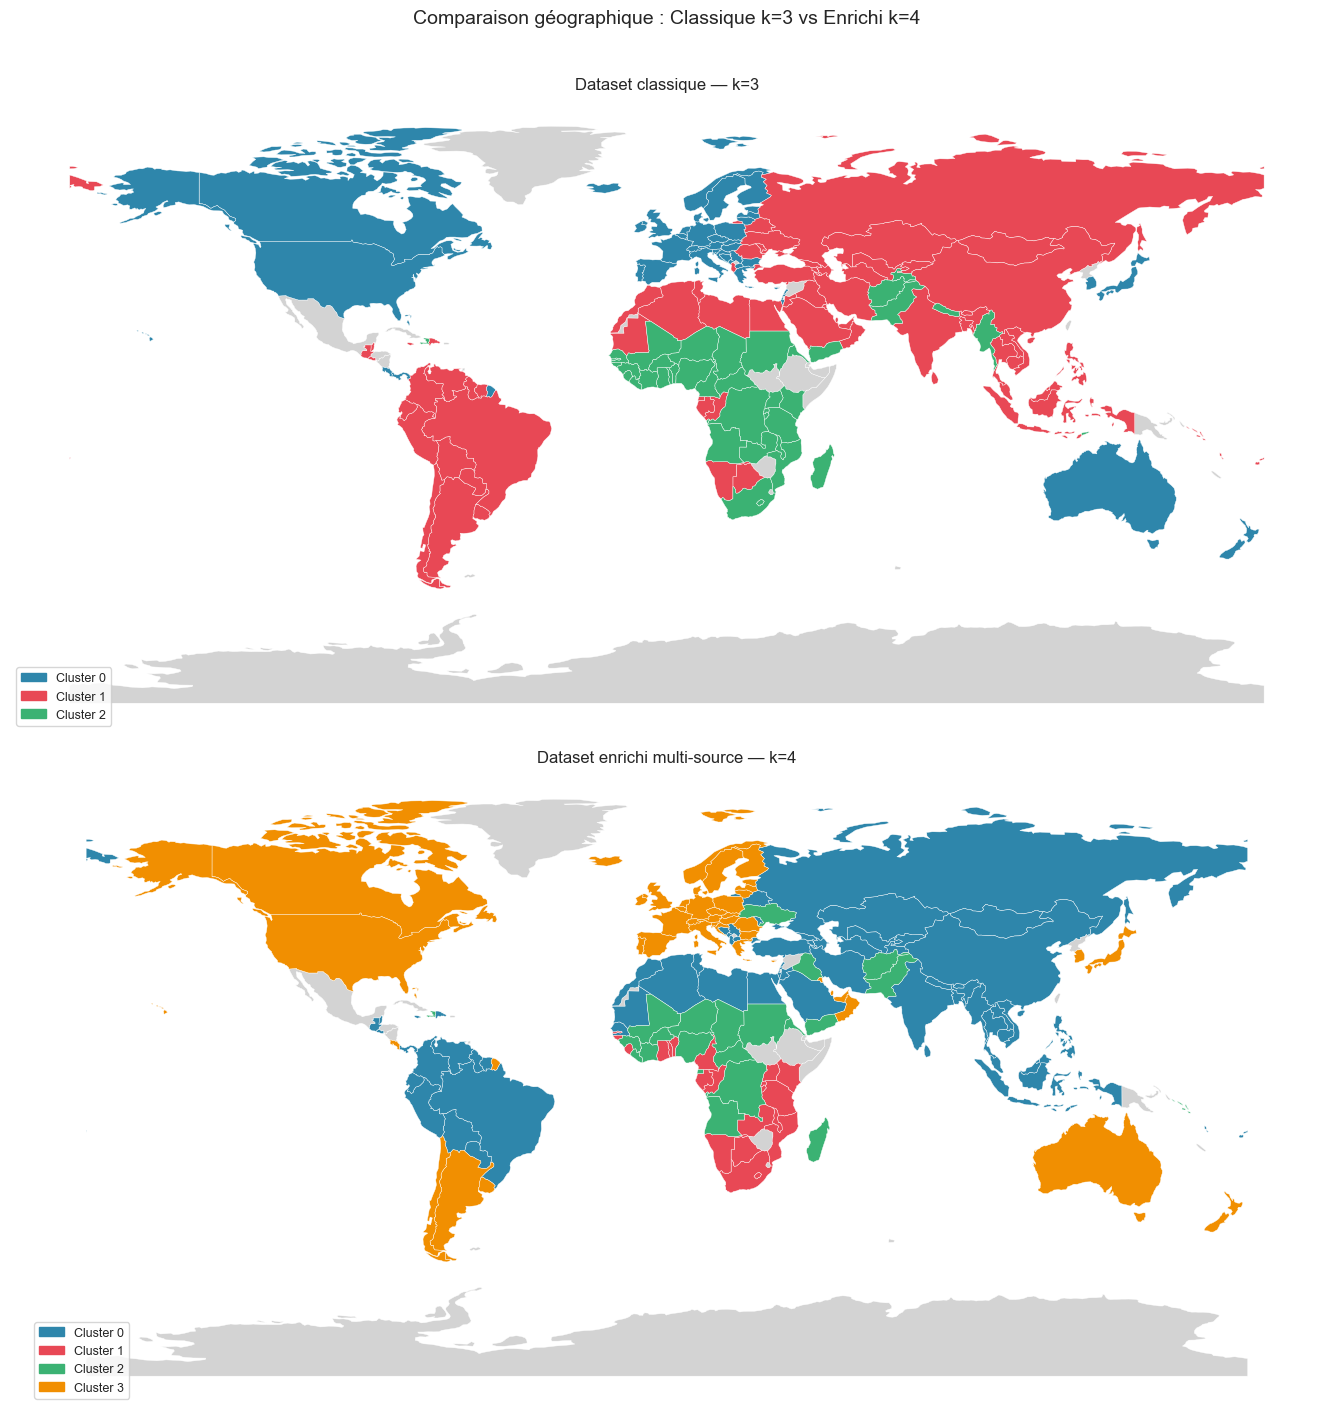

In [83]:
fig, axes = plt.subplots(2, 1, figsize=(16, 14))

# Classique
df_mr2 = df_raw[['country']].copy()
df_mr2['cluster'] = labels_r
df_mr2['country'] = apply_ne_mapping(df_mr2['country'], dataset='classic')
world_r2 = world.merge(df_mr2, left_on='ADMIN', right_on='country', how='left')
world_r2[world_r2['cluster'].isna()].plot(ax=axes[0], color='#D3D3D3', edgecolor='white', linewidth=0.3)
for cl in range(K_FINAL_R):
    world_r2[world_r2['cluster'] == cl].plot(ax=axes[0], color=PALETTE[cl], edgecolor='white', linewidth=0.3)
axes[0].legend(handles=[mpatches.Patch(color=PALETTE[c], label=f'Cluster {c}') for c in range(K_FINAL_R)],
               loc='lower left', fontsize=9)
axes[0].set_title('Dataset classique — k=3', fontsize=12); axes[0].axis('off')

# Enrichi
df_me2 = df_enrich[['country']].copy()
df_me2['cluster'] = labels_e
df_me2['country'] = apply_ne_mapping(df_me2['country'], dataset='enriched')
world_e2 = world.merge(df_me2, left_on='ADMIN', right_on='country', how='left')
world_e2[world_e2['cluster'].isna()].plot(ax=axes[1], color='#D3D3D3', edgecolor='white', linewidth=0.3)
for cl in range(K_FINAL_E):
    world_e2[world_e2['cluster'] == cl].plot(ax=axes[1], color=PALETTE[cl], edgecolor='white', linewidth=0.3)
axes[1].legend(handles=[mpatches.Patch(color=PALETTE[c], label=f'Cluster {c}') for c in range(K_FINAL_E)],
               loc='lower left', fontsize=9)
axes[1].set_title('Dataset enrichi multi-source — k=4', fontsize=12); axes[1].axis('off')

plt.suptitle('Comparaison géographique : Classique k=3 vs Enrichi k=4', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

Les deux cartes confirment la cohérence géographique des partitions, obtenue sans aucune variable de localisation dans le modèle. La carte k=3 (classique) reproduit le schéma bien connu du développement mondial : Europe de l'Ouest, Amérique du Nord, Australasie et Japon en cluster 0 ; Amérique latine, Asie du Sud-Est et Moyen-Orient en cluster 1 ; Afrique subsaharienne en cluster 2. La carte k=4 (enrichi) révèle la structure interne du cluster 2 que k=3 traitait comme un bloc homogène. L'Afrique australe et orientale (Zimbabwe, Botswana, Lesotho, Kenya, Ouganda, Tanzanie, Namibie, Zambie) bascule dans le cluster à crise VIH, distinctement coloré par rapport aux États fragiles du Sahel, de l'Afrique centrale et du Moyen-Orient en crise. Cette différenciation géographique n'est pas un artefact : le modèle a appris ces distinctions uniquement à partir des indicateurs épidémiologiques et institutionnels. Sa correspondance avec les zones géographiques connues valide a posteriori la pertinence des dimensions retenues dans l'enrichissement.

---
# Partie IV : Export des modèles

Les modèles sont sérialisés avec joblib, optimal pour les objets sklearn (compression efficace des arrays numpy internes). Les fichiers de labels et profils sont également exportés en CSV pour usage dans P3 (interprétation) et dans l'application de dashboard.

In [84]:
models_dir = paths.ROOT_DIR / 'models'
models_dir.mkdir(parents=True, exist_ok=True)

# Modèles KMeans
joblib.dump(km_r, models_dir / 'kmeans_k3_classique.joblib')
joblib.dump(km_e, models_dir / 'kmeans_k4_enrichi.joblib')

# Labels + profils
df_cl_r.to_csv(models_dir / 'clusters_classique_k3.csv', index=False)
df_cl_e.to_csv(models_dir / 'clusters_enrichi_k4.csv', index=False)

# Scalers (pour prédiction future)
joblib.dump(scaler_r, models_dir / 'scaler_classique.joblib')
joblib.dump(scaler_e, models_dir / 'scaler_enrichi.joblib')

print('Exports réalisés dans models/ :')
for f in sorted(models_dir.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:45s}  {size_kb:6.1f} Ko')

Exports réalisés dans models/ :
  clusters_classique_k3.csv                        19.4 Ko
  clusters_enrichi_k4.csv                          32.5 Ko
  kmeans_k3_classique.joblib                        1.5 Ko
  kmeans_k4_enrichi.joblib                          1.8 Ko
  scaler_classique.joblib                           1.0 Ko
  scaler_enrichi.joblib                             1.2 Ko


# FIN